In [1]:
import pandas as pd
import numpy as np
import sklearn.model_selection as train_test_split
from openpyxl import load_workbook
from pathlib import Path
import io
import matplotlib
import seaborn as sns   
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
import sklearn.svm as svm
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler   
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression 
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [2]:

class info_modulo():
    def __init__(self, data):
        # inicialización
        self.data = data

    # Crear un dataframe para la df.info()
    def frame_info(self, data):
        buf = io.StringIO()
        data.info(buf=buf)
        s = buf.getvalue()
        lines = [line.split() for line in s.splitlines()[3:-2]]
        return pd.DataFrame(lines)

    def variables_null(self):
        null_columns = self.data.columns[self.data.isnull().any()]
        df_2 = pd.DataFrame(columns=['Nombre Variable', 'Cantidad de Nulos'])
        for col in null_columns:
            nueva_fila = {
                'Nombre Variable': col,
                'Cantidad de Nulos': self.data[col].isnull().sum()
            }
            df_2 = pd.concat([df_2, pd.DataFrame([nueva_fila])], ignore_index=True)
        return df_2

    def variables_nan(self):
        obj_df = self.data.select_dtypes(include=['object'])
        nan_columns = [col for col in obj_df.columns if obj_df[col].isnull().any() or (obj_df[col] == '').any()]
        df_2 = pd.DataFrame(columns=['Nombre Variable', 'Cantidad de Nan o vacíos'])
        for col in nan_columns:
            cantidad = obj_df[col].isnull().sum() + (obj_df[col] == '').sum()
            nueva_fila = {
                'Nombre Variable': col,
                'Cantidad de Nan o vacíos': cantidad
            }
            df_2 = pd.concat([df_2, pd.DataFrame([nueva_fila])], ignore_index=True)
        return df_2

    def info_dataframe(self, ruta = ''):
        print(f"Tamaño: {self.data.shape}")
        print("\n")
        print(f"Variables nulos: ")
        print(self.variables_null())
        print("\n")
        print(f"Variables NAN: ")
        print(self.variables_nan())
        print("\n")    
        print(f"Informacion dataframe: ")
        print(self.data.info())
        print("\n")
        print(f"Datos: ")
        print(self.data.head(10))
        print("\n")
        

In [3]:
df = pd.read_csv('members.csv')
df.head()

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\2553658639.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('members.csv')


,expid,membid,peakid,myear,mseason,fname,lname,sex,yob,citizen,...,death,deathdate,deathtime,deathtype,deathhgtm,deathclass,msmtbid,msmtterm,hcn,mchksum
0,AMAD01101,2,AMAD,2001,Spring,Rohan,Buckley,M,1972.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2439554
1,AMAD01101,1,AMAD,2001,Spring,Marc Cameron,Fairhead,M,1968.0,Australia,...,False,NaN,NaN,NaN,0,NaN,Aborted at high camp,"Bad conditions (deep snow, avalanches, falling...",NaN,2438062
2,AMAD01101,3,AMAD,2001,Spring,Mark,Schroeder,M,1960.0,Australia,...,False,NaN,NaN,NaN,0,NaN,Aborted at high camp,"Bad conditions (deep snow, avalanches, falling...",NaN,2435183
3,AMAD01101,4,AMAD,2001,Spring,Colin,Smith,M,1966.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2437475
4,AMAD01101,5,AMAD,2001,Spring,Naomi,Smith,F,1970.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2438996


In [4]:
df.infomodulo = info_modulo(df)
df.infomodulo.info_dataframe()

Tamaño: (89000, 61)


Variables nulos: 
   Nombre Variable Cantidad de Nulos
0            fname               103
1            lname              1124
2              yob              5408
3          citizen                 7
4        residence              8830
5       occupation             30739
6       mperhighpt             24946
7        msmtdate1             29269
8        msmtdate2             88551
9        msmtdate3             88978
10       msmttime1             62488
11       msmttime2             88756
12       msmttime3             88993
13         mo2note             73653
14       deathdate             87868
15       deathtime             88432
16       deathtype             87842
17      deathclass             87842
18        msmtterm               176
19             hcn             88705


Variables NAN: 
   Nombre Variable Cantidad de Nan o vacíos
0            fname                      103
1            lname                     1124
2          citizen               

In [5]:
df_copy = df.copy()

In [6]:
df_copy['yob'].unique()

array([1972., 1968., 1960., 1966., 1970., 1958., 1956., 1969., 1957.,
       1973., 1971., 1947., 1980., 1976., 1944., 1952., 1974., 1961.,
       1964., 1955., 1967., 1963., 1959., 1945., 1938., 1953., 1943.,
       1975., 1954., 1962., 1965., 1935., 1950., 1951., 1977., 1983.,
       1982., 1939., 1949., 1986., 1942., 1946., 1979., 1978., 1936.,
       1940., 1948., 1981.,   nan, 1941., 1985., 1933., 1934., 1937.,
       1929., 1932., 1930., 1984., 1931., 1928., 1987., 1927., 1988.,
       1989., 1990., 1991., 1992., 1995., 1993., 1994., 1996., 1997.,
       1998., 2000., 1999., 2001., 2002., 2003., 2005., 2004., 2006.,
       2024., 2008., 2007., 1920., 1926., 1924., 1923., 1919., 1922.,
       1917., 1916., 1925., 1921., 1898., 1918., 1915., 1899., 1902.,
       1914., 1904., 1911., 1907., 1908., 1910., 1906., 1913., 1912.,
       1909., 1903., 1885., 1868., 1875., 1865., 1883., 1866., 1884.,
       1894., 1896., 1886., 1887., 1900., 1905., 1901., 1893., 1897.,
       1890., 1882.,

In [7]:
df_copy['myear'].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992,
       1991, 1990, 1989, 1988, 1987, 1986, 1985, 1984, 1983, 1982, 1981,
       1980, 1979, 1978, 1977, 1976, 1975, 1974, 1973, 1972, 1971, 1970,
       1969, 1968, 1967, 1966, 1965, 1964, 1963, 1962, 1961, 1960, 1959,
       1958, 1957, 1956, 1955, 1954, 1953, 1952, 1951, 1950, 1949, 1947,
       1940, 1939, 1938, 1937, 1936, 1935, 1934, 1933, 1931, 1930, 1929,
       1925, 1924, 1922, 1921, 1920, 1910, 1909, 1907, 1905])

In [8]:
df_copy['edad']=df_copy['myear'] - df_copy['yob']
df_copy['edad'].unique()

array([ 29.,  33.,  41.,  35.,  31.,  43.,  45.,  32.,  44.,  28.,  30.,
        54.,  21.,  25.,  57.,  49.,  27.,  40.,  37.,  46.,  34.,  38.,
        42.,  56.,  63.,  48.,  58.,  26.,  47.,  39.,  36.,  66.,  51.,
        50.,  24.,  18.,  19.,  62.,  52.,  15.,  59.,  55.,  22.,  23.,
        65.,  61.,  53.,  20.,  nan,  60.,  16.,  68.,  67.,  64.,  72.,
        69.,  70.,  71.,  74.,  76.,  73.,  75.,  77.,  17.,  78.,  14.,
        79.,  82.,  81.,  84.,  86.,  80.,  83.,  -1., 101., 100.,  97.,
        85.,  92.,  88.,  87.,  12.,  13.,  11.,  10.,   8.,   7.,   9.,
        99., 116., 109., 119., 118.,  90.,  98.,  91.,   4.,   6.,   5.,
         3.,   2., 107.,  96.,  -3.,   1.,   0., 114.,  93.,  89., 111.,
       104.,  95., 105., 103.,  -4.,  -9.,  -2.,  -5.,  -6.,  -8.,  -7.,
       -11., -10., 102., -12., -19., -14., -20., -13., -16., -15., -21.,
       -17., -18., -22., -34., -23., -24., -28., -29., -27., -31., -25.,
       -26., -30., -33., -41., -42., -40., -36., -3

In [9]:

def rellenar_yob_por_edad_promedio_aleatoria(df, yob_col='yob', myear_col='myear', rango=5, random_state=None):
    """
    Rellena los valores faltantes en 'yob' estimando la edad como un valor aleatorio
    dentro del rango edad_promedio ± rango, y restándolo al año de registro.

    Parámetros:
    - df: DataFrame original
    - yob_col: nombre de la columna con el año de nacimiento
    - myear_col: nombre de la columna con el año de registro
    - rango: margen aleatorio alrededor de la edad promedio (por defecto ±5 años)
    - random_state: semilla para reproducibilidad (opcional)

    Devuelve:
    - DataFrame con 'yob' rellenado de manera realista
    """
    df = df.copy()
    rng = np.random.default_rng(seed=random_state)

    # Calcular edad promedio solo con valores razonables
    edades_validas = (df[myear_col] - df[yob_col]).dropna()
    edades_validas = edades_validas[(edades_validas >= 13) & (edades_validas <= 80)]
    edad_promedio = edades_validas.mean().round()

    # Identificar posiciones a rellenar
    mask = df[yob_col].isnull() & df[myear_col].notnull()


    # Generar edades aleatorias en el rango permitido
    cantidad = mask.sum()
    edades_estimadas = rng.integers(edad_promedio - rango, edad_promedio + rango + 1, size=cantidad)

    # Asignar yob = myear - edad aleatoria
    df.loc[mask, yob_col] = df.loc[mask, myear_col].values - edades_estimadas

    return df



In [10]:
df_copy = rellenar_yob_por_edad_promedio_aleatoria(df_copy, yob_col='yob', myear_col='myear', random_state=42)

df_copy['edad'] = df_copy['myear'] - df_copy['yob']

# Crear una máscara para edades inválidas
edad_invalida = (df_copy['edad'] < 13) | (df_copy['edad'] > 80)

# Guardar estos registros aparte
df_edad_fuera_rango = df_copy[edad_invalida].copy()

# Eliminar estos registros del DataFrame original
df_copy = df_copy[~edad_invalida].copy()



In [11]:
df_copy.infomodulo = info_modulo(df_copy)
df_copy.infomodulo.info_dataframe()

Tamaño: (86463, 62)


Variables nulos: 
   Nombre Variable Cantidad de Nulos
0            fname               102
1            lname              1101
2          citizen                 7
3        residence              8682
4       occupation             30090
5       mperhighpt             24043
6        msmtdate1             28197
7        msmtdate2             86018
8        msmtdate3             86441
9        msmttime1             60372
10       msmttime2             86220
11       msmttime3             86456
12         mo2note             71320
13       deathdate             85356
14       deathtime             85907
15       deathtype             85330
16      deathclass             85330
17        msmtterm               176
18             hcn             86174


Variables NAN: 
   Nombre Variable Cantidad de Nan o vacíos
0            fname                      102
1            lname                     1101
2          citizen                        7
3        residence        

In [12]:
# Calcular los límites del boxplot para la columna 'edad'
q1 = df_copy['edad'].quantile(0.25)
q3 = df_copy['edad'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr


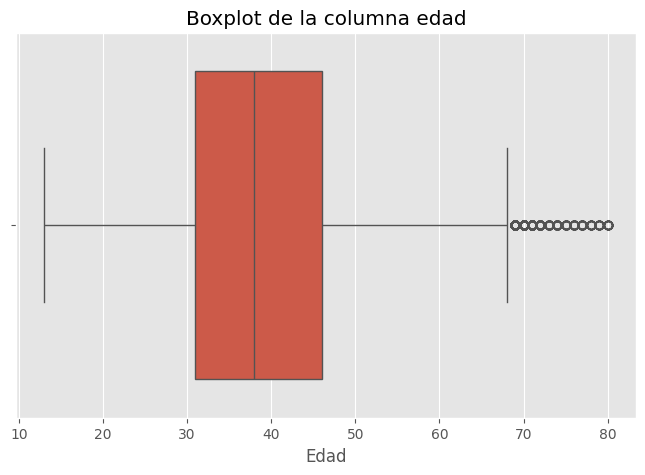

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_copy['edad'])
plt.title('Boxplot de la columna edad')
plt.xlabel('Edad')
plt.show()

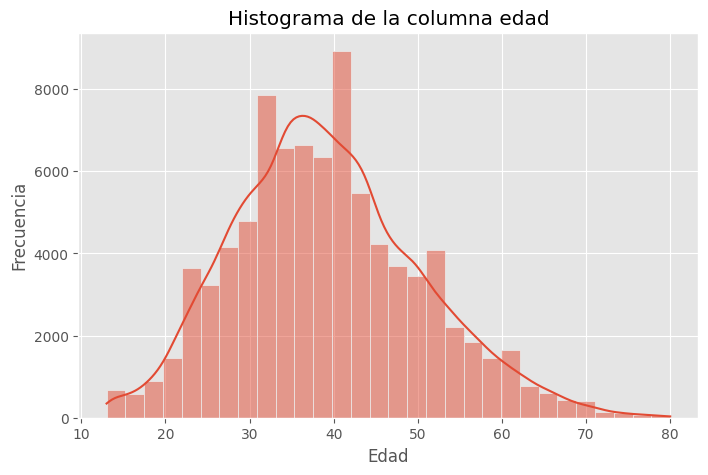

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df_copy['edad'], bins=30, kde=True)
plt.title('Histograma de la columna edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

In [15]:
df_copy['msmtbid'].unique().tolist()
df_copy['msmtbid'].value_counts()

msmtbid
Successful summit bid      36819
No summit bid              25286
Unspecified                11327
Aborted above high camp     8014
Aborted at high camp        2860
Aborted below high camp     2157
Name: count, dtype: int64

In [16]:
df_copy['msmtterm'] = df_copy['msmtterm'].fillna('Unknown')

In [17]:

df_copy['msmtterm'].unique().tolist()
df_copy['msmtterm'].value_counts()


msmtterm
Success                                                     36215
Unspecified                                                 11327
Bad weather (storms, high winds)                             6704
Bad conditions (deep snow, avalanches, falling rock/ice)     5739
Did not climb or intent to summit                            5105
Exhaustion, fatigue, weakness or lack of motivation          2438
Other                                                        2437
Other illnesses or pains                                     2404
Route difficulty, intimidation or insufficient ability       2121
Accident (death or injury to self or others)                 2042
Altitude (AMS symptoms, breathing or unwell)                 1829
Unknown                                                      1682
Assisting, guiding, supporting or accompanying others        1595
Route/camp preparation or rope fixing                        1107
Lack of supplies, support or equipment problems               992
F

In [18]:
df_copy['mperhighpt'].unique().tolist()
df_copy['mperhighpt'].value_counts()

mperhighpt
8849.0    12570
6814.0     6073
8188.0     3874
8163.0     2791
6400.0     1414
          ...  
5715.0        1
6715.0        1
8090.0        1
7490.0        1
7145.0        1
Name: count, Length: 908, dtype: int64

In [19]:
df_copy['deathhgtm'].unique().tolist()
df_copy['deathhgtm'].value_counts()

deathhgtm
0       85369
6500       51
7000       39
6400       37
6800       37
        ...  
3500        1
3860        1
2225        1
2100        1
5040        1
Name: count, Length: 144, dtype: int64

In [20]:
df_copy['occupation'] = df_copy['occupation'].fillna('no information')
df_copy['residence'] = df_copy['residence'].fillna('no information')

In [21]:
df_copy.infodf = info_modulo(df_copy)
df_copy.infodf.info_dataframe()

Tamaño: (86463, 62)


Variables nulos: 
   Nombre Variable Cantidad de Nulos
0            fname               102
1            lname              1101
2          citizen                 7
3       mperhighpt             24043
4        msmtdate1             28197
5        msmtdate2             86018
6        msmtdate3             86441
7        msmttime1             60372
8        msmttime2             86220
9        msmttime3             86456
10         mo2note             71320
11       deathdate             85356
12       deathtime             85907
13       deathtype             85330
14      deathclass             85330
15             hcn             86174


Variables NAN: 
  Nombre Variable Cantidad de Nan o vacíos
0           fname                      102
1           lname                     1101
2         citizen                        7
3       msmtdate1                    28197
4       msmtdate2                    86018
5       msmtdate3                    86441
6         mo

class depurar_dataset:
    def __init__(self, data, target_column):
        self.data = data.copy()
        self.target_column = target_column
        self.columnas_eliminadas = []
        self.columnas_imputadas = {}
        self.columnas_codificadas = []

        self.encoders = {}

    


    def imputar_o_eliminar_nulos(self, porcnull_aceptable=30, metodo='METKNN'):
        columnas_con_nulos = self.data.drop(columns=[self.target_column], errors='ignore').columns[self.data.drop(columns=[self.target_column], errors='ignore').isnull().any()]
        for col in columnas_con_nulos:
            porcentaje = 100 * self.data[col].isnull().sum() / self.data.shape[0]
            if porcentaje >= porcnull_aceptable:
                self.data.drop(col, axis=1, inplace=True)
                self.columnas_eliminadas.append(col)
            else:
                if metodo == 'METKNN':
                    imputer = KNNImputer(n_neighbors=5)
                    self.data[col] = imputer.fit_transform(self.data[[col]])
                    self.columnas_imputadas[col] = 'KNN'
                elif metodo == 'METMEDIA':
                    self.data[col] = SimpleImputer(strategy='mean').fit_transform(self.data[[col]])
                    self.columnas_imputadas[col] = 'Media'
                elif metodo == 'METMODA':
                    self.data[col] = SimpleImputer(strategy='most_frequent').fit_transform(self.data[[col]])
                    self.columnas_imputadas[col] = 'Moda'
                else:
                    self.data.dropna(subset=[col], inplace=True)
                    self.columnas_eliminadas.append(col)

    def eliminar_alta_cardinalidad(self, umbral=35):
        cardinalidad = self.data.drop(columns=[self.target_column], errors='ignore').nunique() * 100 / self.data.shape[0]
        cols = cardinalidad[cardinalidad > umbral].index.tolist()
        self.data.drop(columns=cols, inplace=True)
        self.columnas_eliminadas.extend(cols)

    def eliminar_baja_varianza(self, umbral=0.99):
        for col in self.data.drop(columns=[self.target_column], errors='ignore').columns:
            top_freq = self.data[col].value_counts(normalize=True).max()
            if top_freq > umbral:
                self.data.drop(col, axis=1, inplace=True)
                self.columnas_eliminadas.append(col)

    def eliminar_correlacionadas(self, umbral=0.70):
        corr = self.data.drop(columns=[self.target_column], errors='ignore').corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [col for col in upper.columns if any(upper[col] > umbral)]
        self.data.drop(columns=to_drop, inplace=True)
        self.columnas_eliminadas.extend(to_drop)

    def ejecutar(self, porcnull_aceptable=30, metodo='METKNN', cardinalidad=35, varianza=0.99, correlacion=0.70):
        self.codificar_categoricas()
        self.imputar_o_eliminar_nulos(porcnull_aceptable, metodo)
        self.eliminar_alta_cardinalidad(cardinalidad)
        self.eliminar_baja_varianza(varianza)
        self.eliminar_correlacionadas(correlacion)
        print(f"Columnas eliminadas: {self.columnas_eliminadas}")
        print(f"Columnas imputadas: {self.columnas_imputadas}")
        print(f"Columnas codificadas: {self.columnas_codificadas}")
        print(f"Shape final del DataFrame: {self.data.shape}")
        return self.data



In [22]:
def imputar_o_eliminar_nulos(df, target_column='death', porcnull_aceptable=30, metodo='METKNN'):
    columnas_eliminadas = []
    columnas_imputadas = {}

    # Procesar columnas tipo object (textuales) antes de rellenar
    for col in df.select_dtypes(include='object').columns:
        porcentaje = 100 * df[col].isnull().sum() / df.shape[0]
        if porcentaje >= porcnull_aceptable:
            df.drop(col, axis=1, inplace=True)
            columnas_eliminadas.append(col)
        else:
            df[col] = df[col].astype(str).fillna('no information')
            columnas_imputadas[col] = 'no information'

    # Ahora procesar columnas numéricas con nulos
    columnas_numericas = df.select_dtypes(include=['number']).drop(columns=[target_column], errors='ignore')
    columnas_con_nulos = columnas_numericas.columns[columnas_numericas.isnull().any()]

    for col in columnas_con_nulos:
        porcentaje = 100 * df[col].isnull().sum() / df.shape[0]
        if porcentaje >= porcnull_aceptable:
            df.drop(col, axis=1, inplace=True)
            columnas_eliminadas.append(col)
        else:
            if metodo == 'METKNN':
                imputer = KNNImputer(n_neighbors=5)
                df[[col]] = imputer.fit_transform(df[[col]])
                columnas_imputadas[col] = 'KNN'
            elif metodo == 'METMEDIA':
                df[col] = SimpleImputer(strategy='mean').fit_transform(df[[col]])
                columnas_imputadas[col] = 'Media'
            elif metodo == 'METMODA':
                df[col] = SimpleImputer(strategy='most_frequent').fit_transform(df[[col]])
                columnas_imputadas[col] = 'Moda'
            else:
                df.dropna(subset=[col], inplace=True)
                columnas_eliminadas.append(col)

    print("Columnas eliminadas:", columnas_eliminadas)
    print("Columnas imputadas:", columnas_imputadas)
    return df



In [23]:
imputar_o_eliminar_nulos(df_copy, porcnull_aceptable=30, metodo='METKNN')
df_copy.infodf = info_modulo(df_copy)

Columnas eliminadas: ['msmtdate1', 'msmtdate2', 'msmtdate3', 'mo2note', 'deathdate', 'deathtype', 'deathclass', 'msmttime1', 'msmttime2', 'msmttime3', 'deathtime', 'hcn']
Columnas imputadas: {'expid': 'no information', 'peakid': 'no information', 'mseason': 'no information', 'fname': 'no information', 'lname': 'no information', 'sex': 'no information', 'citizen': 'no information', 'status': 'no information', 'residence': 'no information', 'occupation': 'no information', 'msmtbid': 'no information', 'msmtterm': 'no information', 'mperhighpt': 'KNN'}


In [24]:
df_copy.infodf = info_modulo(df_copy)
df_copy.infodf.info_dataframe()

Tamaño: (86463, 50)


Variables nulos: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nulos]
Index: []


Variables NAN: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nan o vacíos]
Index: []


Informacion dataframe: 
<class 'pandas.core.frame.DataFrame'>
Index: 86463 entries, 0 to 88998
Data columns (total 50 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   expid       86463 non-null  object 
 1   membid      86463 non-null  int64  
 2   peakid      86463 non-null  object 
 3   myear       86463 non-null  int64  
 4   mseason     86463 non-null  object 
 5   fname       86463 non-null  object 
 6   lname       86463 non-null  object 
 7   sex         86463 non-null  object 
 8   yob         86463 non-null  float64
 9   citizen     86463 non-null  object 
 10  status      86463 non-null  object 
 11  residence   86463 non-null  object 
 12  occupation  86463 non-null  object 
 13  leader      86463 non-null  bool   
 14  

columnas_codificadas = []
encoders = {}

def codificar_categoricas(df,columnas_a_codificar=['msmtbid', 'msmtterm']):
        for col in columnas_a_codificar:
            if col in df.columns:
                df[col] = df[col].astype(str).fillna("MISSING")
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col])
                encoders[col] = le
                columnas_codificadas.append(col)
            else:
                print(f"[AVISO] Columna '{col}' no encontrada en el DataFrame")

# Reemplaza 'msuccess' por el nombre real de tu columna objetivo si es diferente
codificar_categoricas(df_copy,columnas_a_codificar=['msmtbid', 'msmtterm'])


In [25]:
# Definir los bins de edad (por ejemplo, cada 5 años)
bins = list(range(int(df_copy['edad'].min()), int(df_copy['edad'].max()) + 5, 5))
labels = [f"{b}-{b+4}" for b in bins[:-1]]

# Crear una nueva columna de rango de edad
df_copy['edad_rango'] = pd.cut(df_copy['edad'], bins=bins, labels=labels, right=False)

# Agrupar por rango de edad y sexo
grouped_rango = df_copy.groupby(['edad_rango', 'sex']).size().unstack(fill_value=0)
grouped_rango

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\2889544508.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_rango = df_copy.groupby(['edad_rango', 'sex']).size().unstack(fill_value=0)


sex,F,M,X
edad_rango,,,
13-17,144,1111,0
18-22,289,3089,1
23-27,681,7169,0
28-32,1247,10855,0
33-37,1651,14246,0
38-42,1443,13832,0
43-47,1203,10386,0
48-52,934,7182,0
53-57,522,4766,0


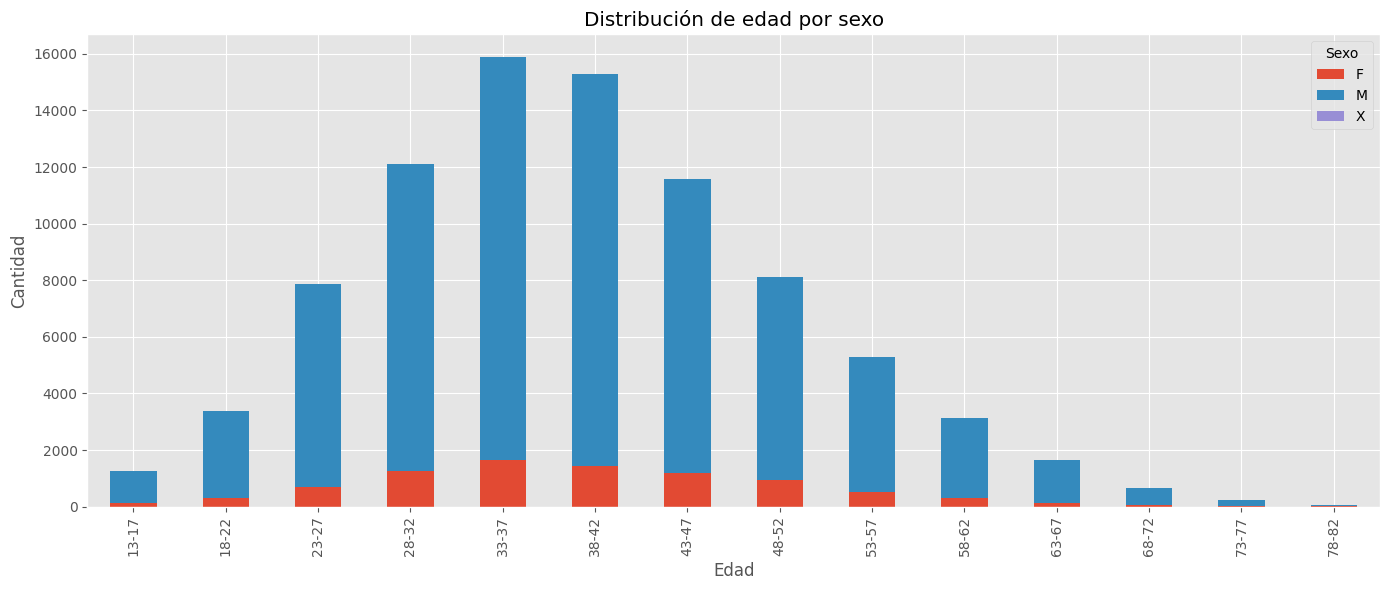

In [26]:
# Graficar el resultado como barras apiladas
ax = grouped_rango.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Distribución de edad por sexo')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

# Calcular totales por temporada
totalesxrango = grouped_rango.sum(axis=1)

# Añadir porcentajes sobre cada barra
for i, m in enumerate(grouped_rango.index):
    for j, f in enumerate(grouped_rango.columns):
        valor = grouped_rango.loc[m, f]
        porcentaje = valor / totalesxrango[m] * 100 if totalesxrango[m] > 0 else 0
        # Ajustar la posición horizontal de las etiquetas para que no se superpongan
        ax.text(i + (j - 0.5) * 0.2, valor + max(grouped_rango.max()) * 0.01, f'{porcentaje:.1f}%', 
                ha='center', va='bottom', fontsize=10)

myear
1905       2
1907       1
1920       2
1921       7
1922      12
        ... 
2020     239
2021    2172
2022    3305
2023    3489
2024    1708
Name: membid, Length: 91, dtype: int64


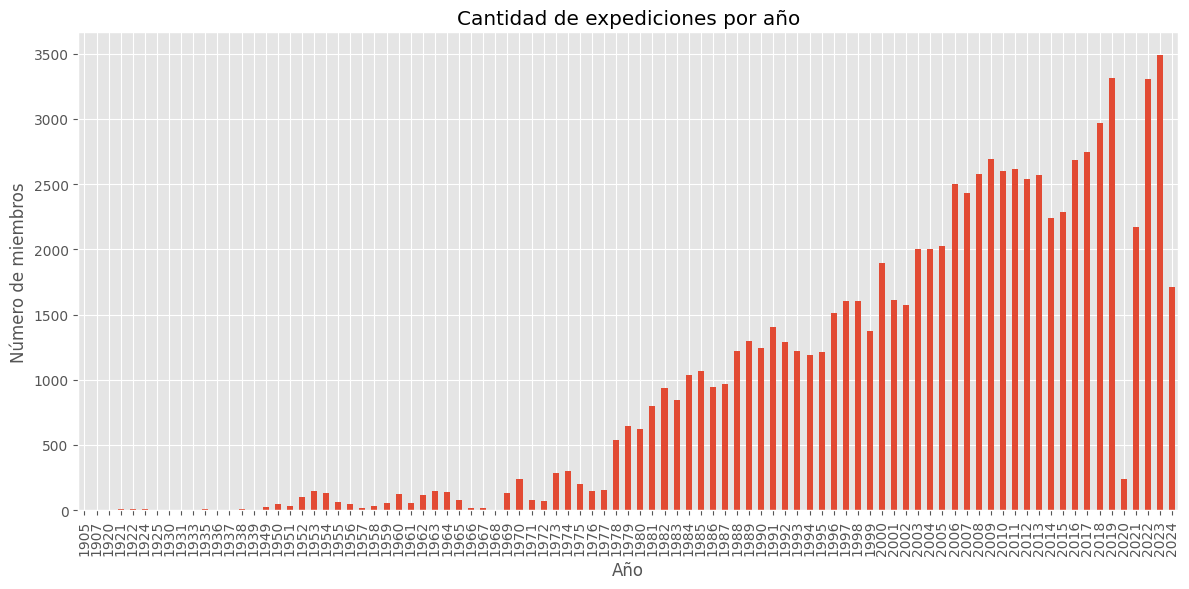

In [27]:
# Agrupar por año y contar la cantidad de miembros por año
expediciones_por_anio = df_copy.groupby('myear')['membid'].count()
print(expediciones_por_anio)

plt.figure(figsize=(12, 6))
expediciones_por_anio.plot(kind='bar')
plt.title('Cantidad de expediciones por año')
plt.xlabel('Año')
plt.ylabel('Número de miembros')
plt.tight_layout()
plt.show()

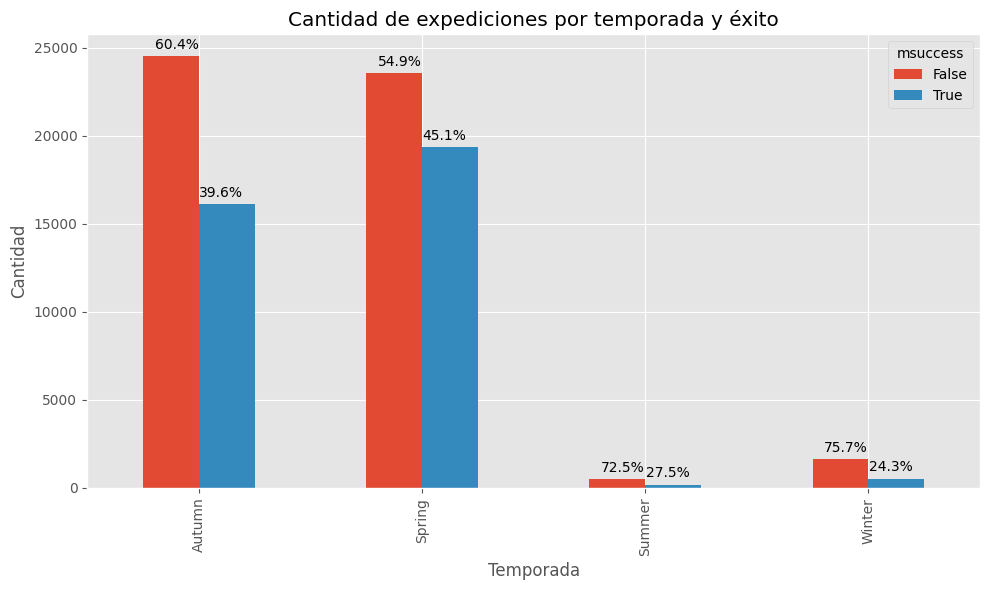

In [28]:
# Agrupar por temporada y éxito
conteo = df_copy.groupby(['mseason', 'msuccess']).size().unstack(fill_value=0)

# Graficar barras agrupadas
ax = conteo.plot(kind='bar', figsize=(10,6))
plt.title('Cantidad de expediciones por temporada y éxito')
plt.xlabel('Temporada')
plt.ylabel('Cantidad')
plt.legend(title='msuccess')
plt.tight_layout()

# Agregar porcentaje sobre cada barra
totales = conteo.sum(axis=1)
for i, temporada in enumerate(conteo.index):
    for j, exito in enumerate(conteo.columns):
        valor = conteo.loc[temporada, exito]
        porcentaje = valor / totales[temporada] * 100 if totales[temporada] > 0 else 0
        ax.text(i + (j - 0.5) * 0.2, valor + max(conteo.max()) * 0.01, f'{porcentaje:.1f}%', 
                ha='center', va='bottom', fontsize=10)

plt.show()

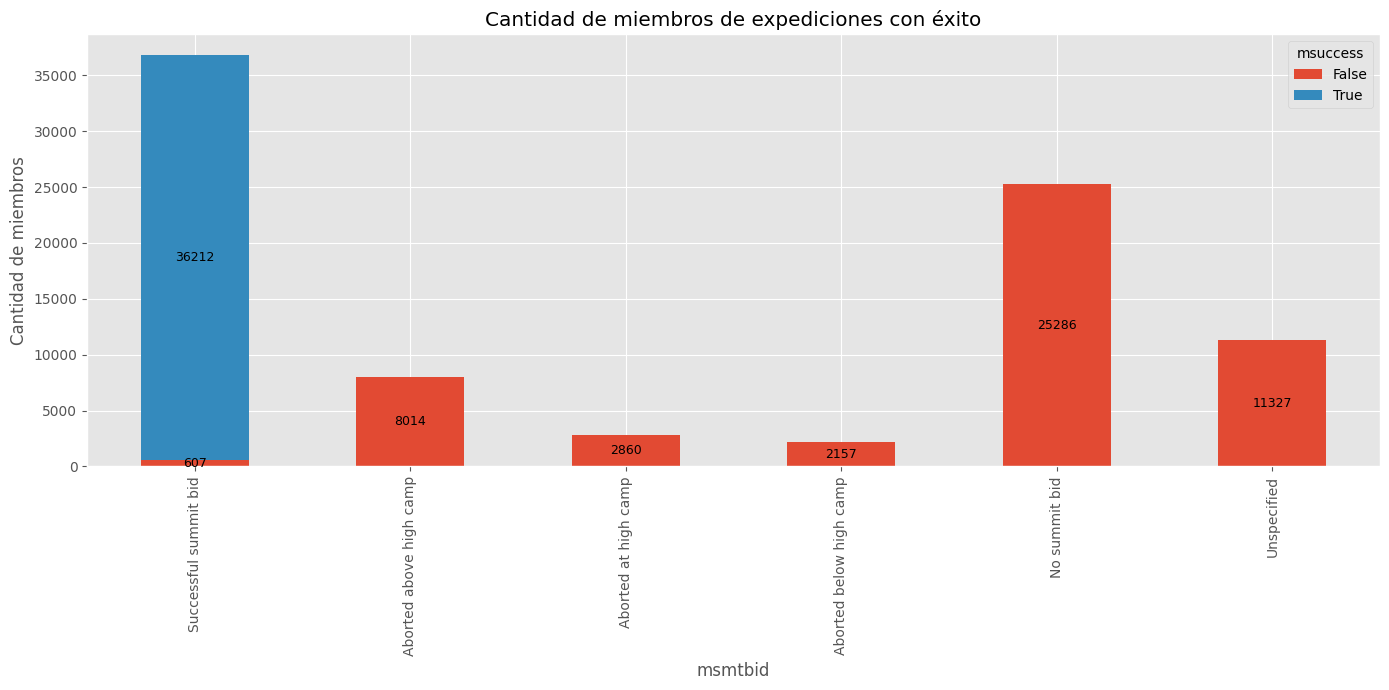

In [29]:
# Agrupar por 'msmtbid' y 'msuccess', contar miembros únicos por cada combinación
miembros_por_msmtbid_success = df_copy.groupby(['msmtbid', 'msuccess'])['expid'].count().unstack(fill_value=0).sort_values(by=True, ascending=False)

ax = miembros_por_msmtbid_success.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Cantidad de miembros de expediciones con éxito')
plt.xlabel('msmtbid')
plt.ylabel('Cantidad de miembros')
plt.legend(title='msuccess')
plt.tight_layout()

# Añadir cantidades sobre cada barra (para cada segmento)
for i, msmtbid in enumerate(miembros_por_msmtbid_success.index):
    for j, success in enumerate(miembros_por_msmtbid_success.columns):
        valor = miembros_por_msmtbid_success.loc[msmtbid, success]
        if valor > 0:
            ax.text(i, miembros_por_msmtbid_success.loc[msmtbid].cumsum()[success] - valor/2,
                    str(valor), ha='center', va='center', fontsize=9, color='black')

plt.show()

In [30]:
totales_msmtbid = df_copy.groupby('msmtbid').size().sort_values(ascending=False)
totales_msmtbid


msmtbid
Successful summit bid      36819
No summit bid              25286
Unspecified                11327
Aborted above high camp     8014
Aborted at high camp        2860
Aborted below high camp     2157
dtype: int64

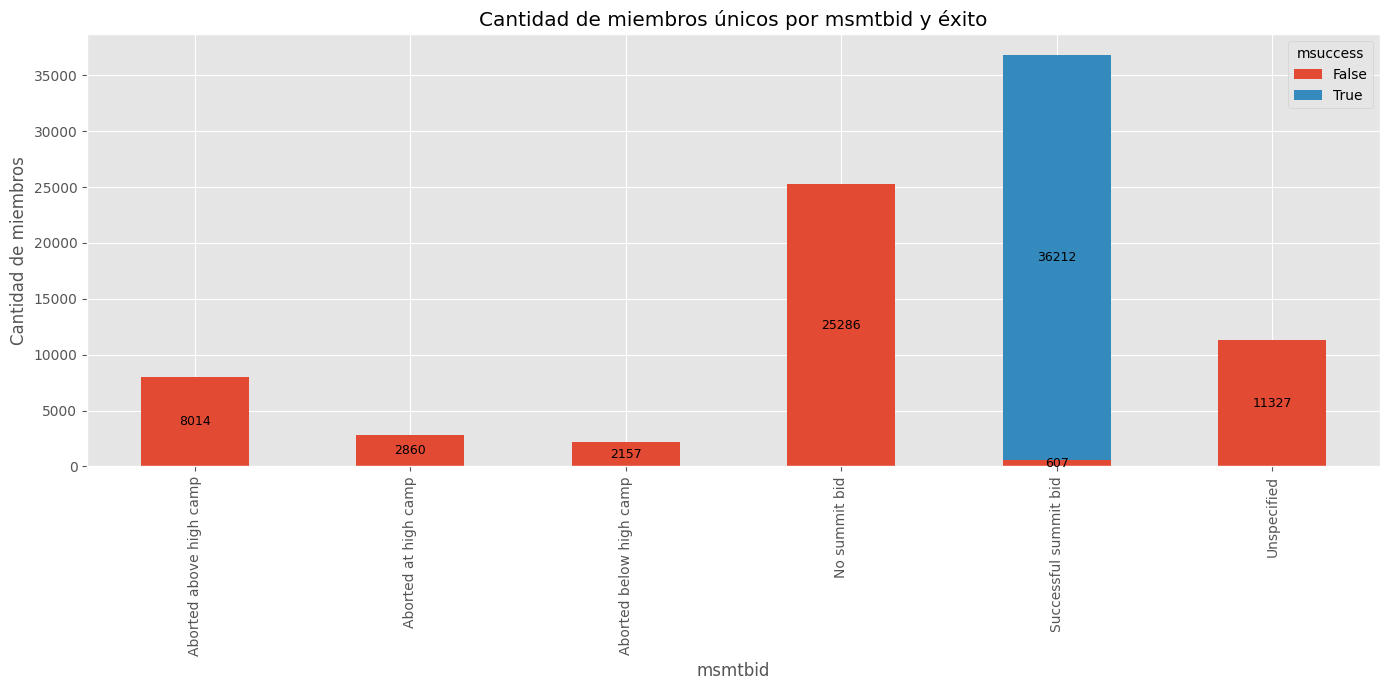

In [31]:
miembros_por_msmtbid_success = df_copy.groupby(['msmtbid', 'msuccess'])['membid'].count().unstack(fill_value=0)

ax = miembros_por_msmtbid_success.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Cantidad de miembros únicos por msmtbid y éxito')
plt.xlabel('msmtbid')
plt.ylabel('Cantidad de miembros')
plt.legend(title='msuccess')
plt.tight_layout()

# Añadir cantidades sobre cada barra (para cada segmento)
for i, msmtbid in enumerate(miembros_por_msmtbid_success.index):
    for j, success in enumerate(miembros_por_msmtbid_success.columns):
        valor = miembros_por_msmtbid_success.loc[msmtbid, success]
        if valor > 0:
            ax.text(i, miembros_por_msmtbid_success.loc[msmtbid].cumsum()[success] - valor/2,
                    str(valor), ha='center', va='center', fontsize=9, color='black')

In [32]:
print(f"cantidad de valores unicos: {df_copy['membid'].nunique()}")
print(f"cantidad de valores unicos: {df_copy['expid'].nunique()}")

cantidad de valores unicos: 99
cantidad de valores unicos: 11315


In [33]:
# Agrupar por ocupación y éxito, contar miembros únicos por cada combinación
occupation_success = df_copy.groupby(['occupation', 'msuccess'])['membid'].count().unstack(fill_value=0)
occupation_success = occupation_success.sort_values(by=True, ascending=False)
print(occupation_success.head(10))



msuccess           False  True 
occupation                     
no information     12164  17926
Alpine guide        3505   2594
Physician           1731    571
Engineer            1049    531
Alpinist             476    407
Student              582    379
Teacher              450    211
Attorney             405    203
Alpine instructor    236    156
Businessman          225    147


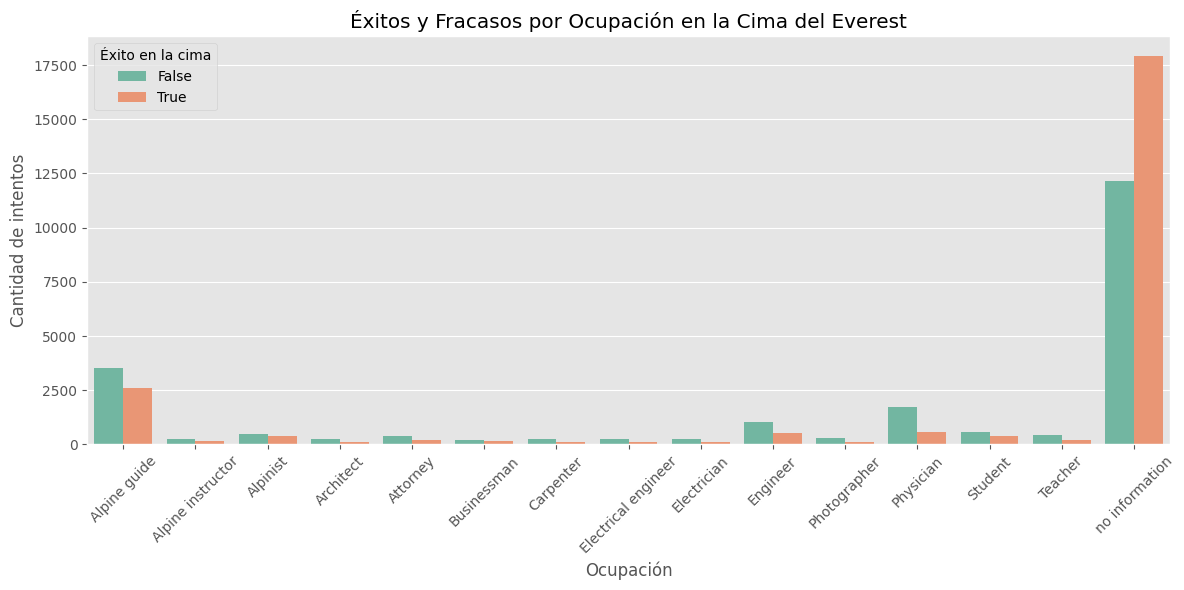

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupamos por ocupación y éxito
occupation_success = (
    df_copy
    .groupby(['occupation', 'msuccess'])['membid']
    .count()
    .reset_index()
)

# Filtramos las 10 ocupaciones con más éxito (True)
top_15_ocupaciones = (
    occupation_success[occupation_success['msuccess'] == True]
    .sort_values(by='membid', ascending=False)
    .head(15)['occupation']
)

# Filtramos el dataframe para solo esas ocupaciones
datos_top15 = occupation_success[occupation_success['occupation'].isin(top_15_ocupaciones)]

# Graficamos
plt.figure(figsize=(12, 6))
sns.barplot(
    data=datos_top15,
    x='occupation',
    y='membid',
    hue='msuccess',
    palette='Set2'
)
plt.title('Éxitos y Fracasos por Ocupación en la Cima del Everest')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de intentos')
plt.xlabel('Ocupación')
plt.legend(title='Éxito en la cima')
plt.tight_layout()
plt.show()


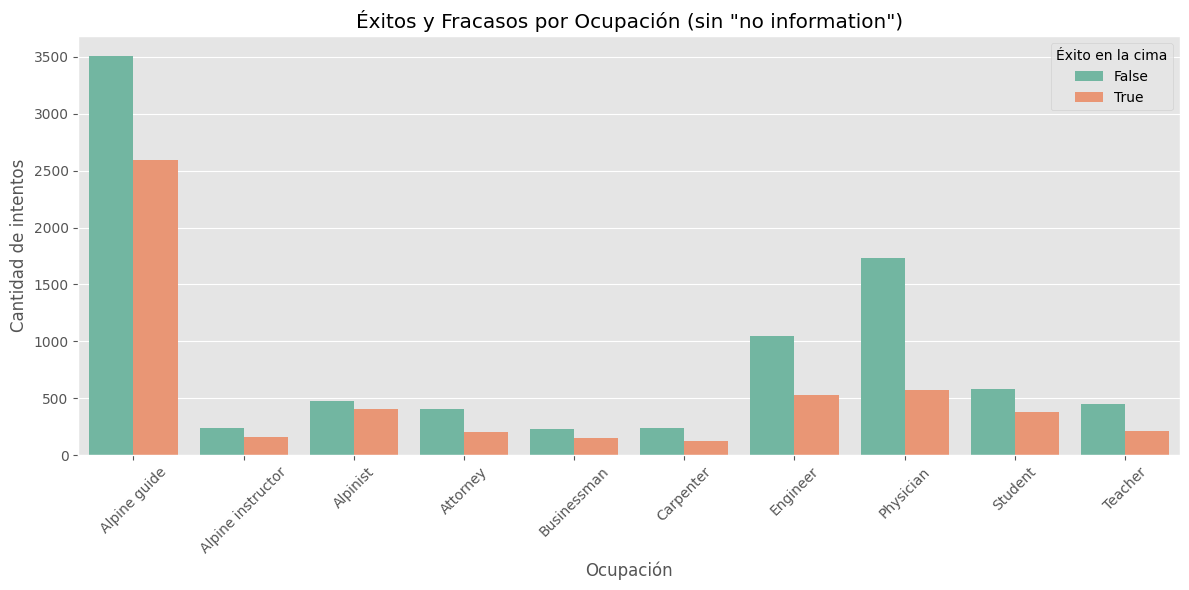

In [35]:

# Agrupar por ocupación y éxito
occupation_success = (
    df_copy
    .groupby(['occupation', 'msuccess'])['membid']
    .count()
    .reset_index()
)

# Filtrar fuera 'no information'
occupation_success = occupation_success[occupation_success['occupation'] != 'no information']

# Obtener las 10 ocupaciones con más casos de éxito
top_10_ocupaciones = (
    occupation_success[occupation_success['msuccess'] == True]
    .sort_values(by='membid', ascending=False)
    .head(10)['occupation']
)

# Filtrar solo esas ocupaciones
datos_top10 = occupation_success[occupation_success['occupation'].isin(top_10_ocupaciones)]

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(
    data=datos_top10,
    x='occupation',
    y='membid',
    hue='msuccess',
    palette='Set2'
)
plt.title('Éxitos y Fracasos por Ocupación (sin "no information")')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de intentos')
plt.xlabel('Ocupación')
plt.legend(title='Éxito en la cima')
plt.tight_layout()
plt.show()


In [36]:
mo2_success = df_copy.groupby(['mo2used', 'msuccess'])['membid'].count().unstack(fill_value=0)
mo2_success = mo2_success.sort_values(by=True, ascending=False)
print(mo2_success.head())

msuccess  False  True 
mo2used               
True       4485  18883
False     45766  17329


In [37]:

death_success = df_copy.groupby(['mo2used', 'death'])['membid'].count().unstack(fill_value=0)
death_success = death_success.sort_values(by=True, ascending=False)
print(death_success.head())

death    False  True 
mo2used              
False    62195    900
True     23135    233


In [38]:
death_member = df_copy.groupby(['death'])['membid'].count()
death_member = death_member.sort_values(ascending=False)
print(death_member.head())

death
False    85330
True      1133
Name: membid, dtype: int64


In [39]:
death_exp = df_copy.groupby(['death'])['expid'].count()
death_exp = death_exp.sort_values(ascending=False)
print(death_exp.head())

death
False    85330
True      1133
Name: expid, dtype: int64


In [40]:
# Agrupar por expedición y contar cuántos murieron
muertes_por_expedicion = df_copy[df_copy['death'] == True].groupby('expid')['death'].count()

# Ordenar de mayor a menor
muertes_por_expedicion = muertes_por_expedicion.sort_values(ascending=False)

# Mostrar las 10 expediciones con más muertes
print("Top 10 expediciones con más muertes:")
print(muertes_por_expedicion.head(20))


Top 10 expediciones con más muertes:
expid
KGUR05301    18
MANA72101    15
PISA94301    10
GURJ18301     9
GANG71301     8
EVER22101     7
DHA169101     7
DHA469301     6
EVER74301     6
EVER70101     6
ANN191301     6
MAKA02104     6
EVER15159     6
EVER24109     5
DHA114301     5
KANG05201     5
DHA175101     5
EVER89103     5
EVER85303     5
PUMO01302     5
Name: death, dtype: int64


In [41]:
# Obtener la expedición con más muertes
expedicion_tragica = muertes_por_expedicion.idxmax()
muertes = muertes_por_expedicion.max()

print(f"La expedición más trágica fue '{expedicion_tragica}' con {muertes} muertes.")

# Ver más detalles sobre esa expedición
df_tragica = df_copy[df_copy['expid'] == expedicion_tragica]
print(df_tragica[['membid', 'myear', 'death', 'expid', 'msmtbid','msmtterm', 'mseason']])


La expedición más trágica fue 'KGUR05301' con 18 muertes.
      membid  myear  death      expid        msmtbid  \
8579       2   2005   True  KGUR05301  No summit bid   
8580       3   2005   True  KGUR05301  No summit bid   
8581       4   2005   True  KGUR05301  No summit bid   
8582       5   2005   True  KGUR05301  No summit bid   
8583       6   2005   True  KGUR05301  No summit bid   
8584       1   2005   True  KGUR05301  No summit bid   
8585       7   2005   True  KGUR05301  No summit bid   
8619      12   2005   True  KGUR05301  No summit bid   
8620      18   2005   True  KGUR05301  No summit bid   
8621      17   2005   True  KGUR05301  No summit bid   
8622      16   2005   True  KGUR05301  No summit bid   
8623      10   2005   True  KGUR05301  No summit bid   
8624       9   2005   True  KGUR05301  No summit bid   
8625      14   2005   True  KGUR05301  No summit bid   
8626       8   2005   True  KGUR05301  No summit bid   
8627      11   2005   True  KGUR05301  No summ

In [42]:
# Agrupar por expedición: contar miembros y sumar muertes
resumen_expediciones = df_copy.groupby('expid').agg(
    cantidad_miembros=('membid', 'count'),
    cantidad_muertes=('death', 'sum')
)


In [43]:
exp_mas_miembros = resumen_expediciones.sort_values(by='cantidad_miembros', ascending=False).head(1)
print("Expedición con más miembros:")
print(exp_mas_miembros)


Expedición con más miembros:
           cantidad_miembros  cantidad_muertes
expid                                         
EVER88101                 98                 1


In [44]:
exp_menos_miembros = resumen_expediciones.sort_values(by='cantidad_miembros', ascending=True).head(1)
print("Expedición con menos miembros:")
print(exp_menos_miembros)


Expedición con menos miembros:
           cantidad_miembros  cantidad_muertes
expid                                         
LHOT08103                  1                 0


In [45]:
promedio_miembros = resumen_expediciones['cantidad_miembros'].mean()
print(f"Promedio de miembros por expedición: {promedio_miembros:.2f}")


Promedio de miembros por expedición: 7.64


In [46]:
df_copy['peakid'].unique()
df_copy['peakid'].value_counts()

peakid
EVER    24714
AMAD    10949
CHOY     8787
MANA     6477
LHOT     3233
        ...  
PHOL        2
BHUL        2
JASG        2
SNOW        1
KHUM        1
Name: count, Length: 414, dtype: int64

In [47]:
df_everest = df_copy[df_copy['peakid'] == 'EVER']

In [48]:
death_success_ever = df_everest.groupby(['mo2used', 'death'])['membid'].count().unstack(fill_value=0)
death_success_ever = death_success_ever.sort_values(by=True, ascending=False)
print(death_success_ever.head())

death    False  True 
mo2used              
False     9330    186
True     15053    145


In [49]:
death_member_ever = df_everest.groupby('death')['membid'].count().sort_values(ascending=False)
print(death_member_ever.head())

death
False    24383
True       331
Name: membid, dtype: int64


In [50]:
# Agrupar por expedición y contar cuántos murieron
muertes_por_expedicion_ever = df_everest[df_everest['death'] == True].groupby('expid')['death'].count()

# Ordenar de mayor a menor
muertes_por_expedicion_ever = muertes_por_expedicion_ever.sort_values(ascending=False)

# Mostrar las 10 expediciones con más muertes
print("Top 10 expediciones con más muertes:")
print(muertes_por_expedicion_ever.head(20))

Top 10 expediciones con más muertes:
expid
EVER22101    7
EVER15159    6
EVER70101    6
EVER74301    6
EVER24109    5
EVER89103    5
EVER85303    5
EVER82302    4
EVER88308    4
EVER14114    4
EVER96115    4
EVER96110    3
EVER90306    3
EVER97108    3
EVER16148    3
EVER23102    3
EVER79302    3
EVER24101    3
EVER15154    3
EVER14108    3
Name: death, dtype: int64


In [51]:
# Obtener la expedición con más muertes
expedicion_tragica_ever = muertes_por_expedicion_ever.idxmax()
muertes_ever = muertes_por_expedicion_ever.max()

print(f"La expedición más trágica fue '{expedicion_tragica_ever}' con {muertes_ever} muertes.")

# Ver más detalles sobre esa expedición
df_tragica_ever = df_everest[df_everest['expid'] == expedicion_tragica_ever]
print(df_tragica_ever[['membid', 'myear', 'death', 'expid', 'msmtbid','msmtterm', 'mseason']])

La expedición más trágica fue 'EVER22101' con 7 muertes.
       membid  myear  death      expid                  msmtbid  \
48488       1   2022  False  EVER22101    Successful summit bid   
48489       2   2022  False  EVER22101    Successful summit bid   
48490       3   2022  False  EVER22101    Successful summit bid   
48491       4   2022  False  EVER22101    Successful summit bid   
48492       5   2022  False  EVER22101    Successful summit bid   
48493       6   2022  False  EVER22101    Successful summit bid   
48494       7   2022  False  EVER22101    Successful summit bid   
48495       8   2022  False  EVER22101    Successful summit bid   
48496       9   2022  False  EVER22101    Successful summit bid   
48497      10   2022  False  EVER22101    Successful summit bid   
48498      11   2022  False  EVER22101    Successful summit bid   
80374      18   1982   True  EVER22101            No summit bid   
80375      17   1982   True  EVER22101            No summit bid   
80376

In [52]:
# Agrupar por expedición: contar miembros y sumar muertes
resumen_expediciones_ever = df_everest.groupby('expid').agg(
    cantidad_miembros=('membid', 'count'),
    cantidad_muertes=('death', 'sum'))

In [53]:
exp_mas_miembros_ever = resumen_expediciones_ever.sort_values(by='cantidad_miembros', ascending=False).head(1)
print("Expedición con más miembros:")
print(exp_mas_miembros_ever)

Expedición con más miembros:
           cantidad_miembros  cantidad_muertes
expid                                         
EVER88101                 98                 1


In [54]:
exp_menos_miembros_ever = resumen_expediciones_ever.sort_values(by='cantidad_miembros', ascending=True).head(1)
print("Expedición con menos miembros:")
print(exp_menos_miembros_ever)


Expedición con menos miembros:
           cantidad_miembros  cantidad_muertes
expid                                         
EVER99133                  1                 0


In [55]:
promedio_miembros_ever = resumen_expediciones_ever['cantidad_miembros'].mean()
print(f"Promedio de miembros por expedición: {promedio_miembros_ever:.2f}")


Promedio de miembros por expedición: 10.60


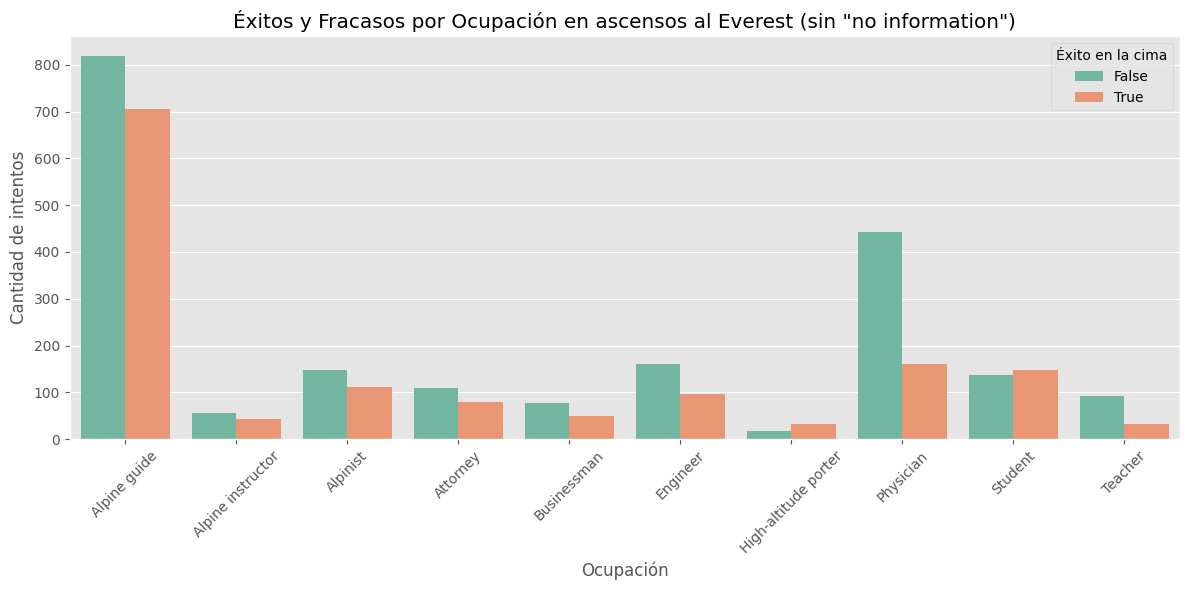

In [56]:
# Agrupar por ocupación y éxito
occupation_success_ever = (
    df_everest
    .groupby(['occupation', 'msuccess'])['membid']
    .count()
    .reset_index()
)

# Filtrar fuera 'no information'
occupation_success_ever = occupation_success_ever[occupation_success_ever['occupation'] != 'no information']

# Obtener las 10 ocupaciones con más casos de éxito
top_10_ocupaciones_ever = (
    occupation_success_ever[occupation_success_ever['msuccess'] == True]
    .sort_values(by='membid', ascending=False)
    .head(10)['occupation']
)

# Filtrar solo esas ocupaciones
datos_top10 = occupation_success_ever[occupation_success_ever['occupation'].isin(top_10_ocupaciones_ever)]

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(
    data=datos_top10,
    x='occupation',
    y='membid',
    hue='msuccess',
    palette='Set2'
)
plt.title('Éxitos y Fracasos por Ocupación en ascensos al Everest (sin "no information")')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de intentos')
plt.xlabel('Ocupación')
plt.legend(title='Éxito en la cima')
plt.tight_layout()
plt.show()

myear
1949       5
1950      34
1951      25
1952      48
1953      25
1954      47
1955      32
1956      19
1958      11
1959      10
1960      39
1962      10
1963      10
1964      12
1965      16
1969      21
1970      61
1971       4
1973      83
1974      56
1975      77
1976     136
1978     151
1979     111
1980      60
1981     289
1982     173
1983      37
1984      30
1989       2
1991     347
1992    1291
1993    1222
1994    1192
1995     924
2001     468
2002     320
2003     660
2004     575
2005     674
2006     786
2007     938
2008     634
2009     795
2010     790
2011     836
2012     873
2013     900
2014     519
2015     903
2016     893
2017     969
2018    1030
2019    1136
2020      38
2021     719
2022     792
2023     894
2024     962
Name: membid, dtype: int64


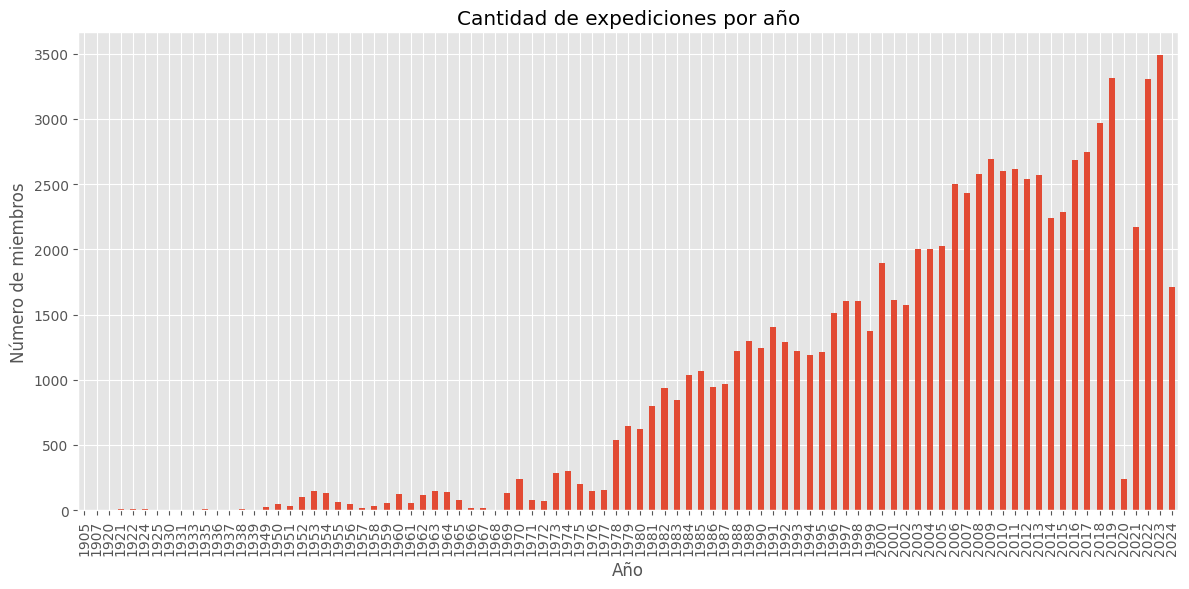

In [57]:
expediciones_por_anio_everest = df_everest.groupby('myear')['membid'].count()
print(expediciones_por_anio_everest)

plt.figure(figsize=(12, 6))
expediciones_por_anio.plot(kind='bar')
plt.title('Cantidad de expediciones por año')
plt.xlabel('Año')
plt.ylabel('Número de miembros')
plt.tight_layout()
plt.show()

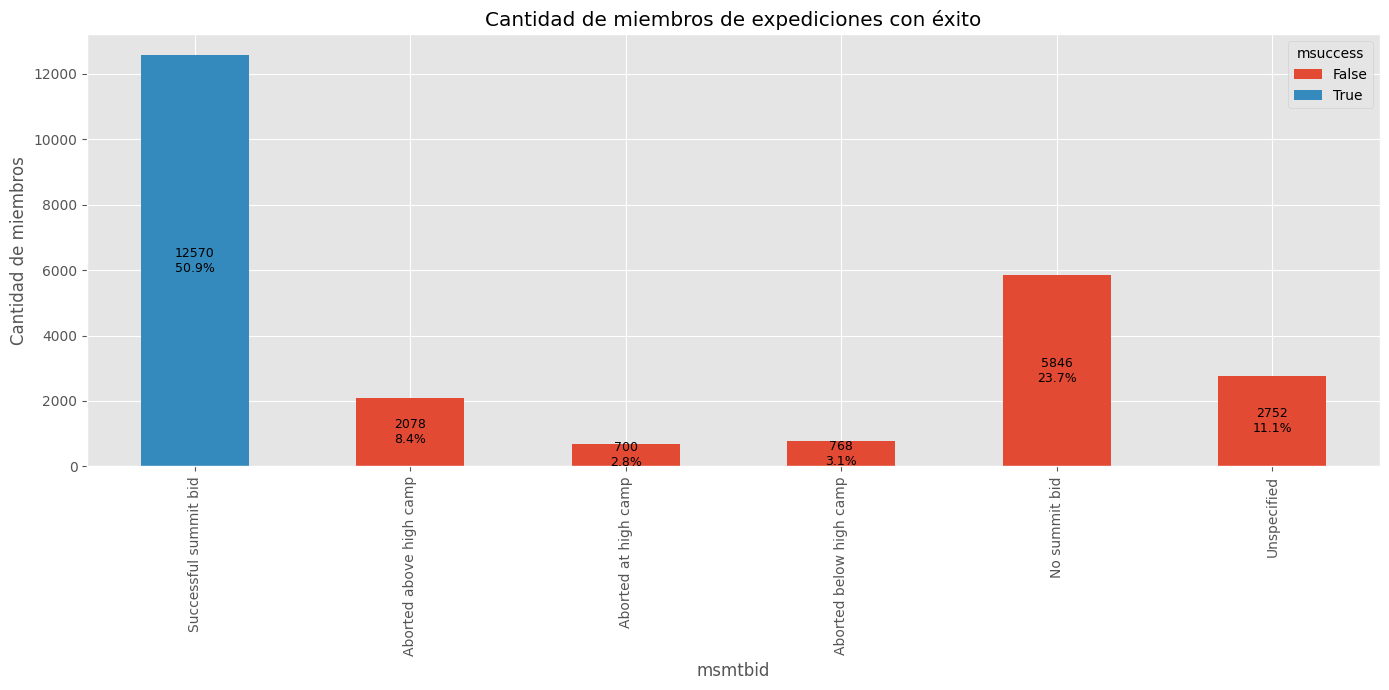

In [58]:
# Agrupar por 'msmtbid' y 'msuccess', contar miembros únicos por cada combinación
miembros_success_everest = df_everest.groupby(['msmtbid', 'msuccess'])['expid'].count().unstack(fill_value=0).sort_values(by=True, ascending=False)

ax = miembros_success_everest.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Cantidad de miembros de expediciones con éxito')
plt.xlabel('msmtbid')
plt.ylabel('Cantidad de miembros')
plt.legend(title='msuccess')
plt.tight_layout()
total_general = miembros_success_everest.values.sum()
# Añadir cantidades sobre cada barra (para cada segmento)
for i, msmtbid in enumerate(miembros_success_everest.index):
    for j, success in enumerate(miembros_success_everest.columns):
        valor = miembros_success_everest.loc[msmtbid, success]
        porcentaje = valor / total_general * 100 if total_general > 0 else 0
        if valor > 0:
            ax.text(i, miembros_success_everest.loc[msmtbid].cumsum()[success] - valor/2,
                    f'{valor}\n{porcentaje:.1f}%',
                    ha='center', va='center', fontsize=9, color='black')

plt.show()

In [59]:
# Reemplazar los valores 'Other' por 'Unspecified' en la columna 'msmtterm'
df_everest['msmtterm'] = df_everest['msmtterm'].replace('Other', 'Unspecified')
df_everest['msmtterm'] = df_everest['msmtterm'].replace('Unknown', 'Unspecified')

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\1718079768.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_everest['msmtterm'] = df_everest['msmtterm'].replace('Other', 'Unspecified')
C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\1718079768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_everest['msmtterm'] = df_everest['msmtterm'].replace('Unknown', 'Unspecified')


C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\2656802384.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


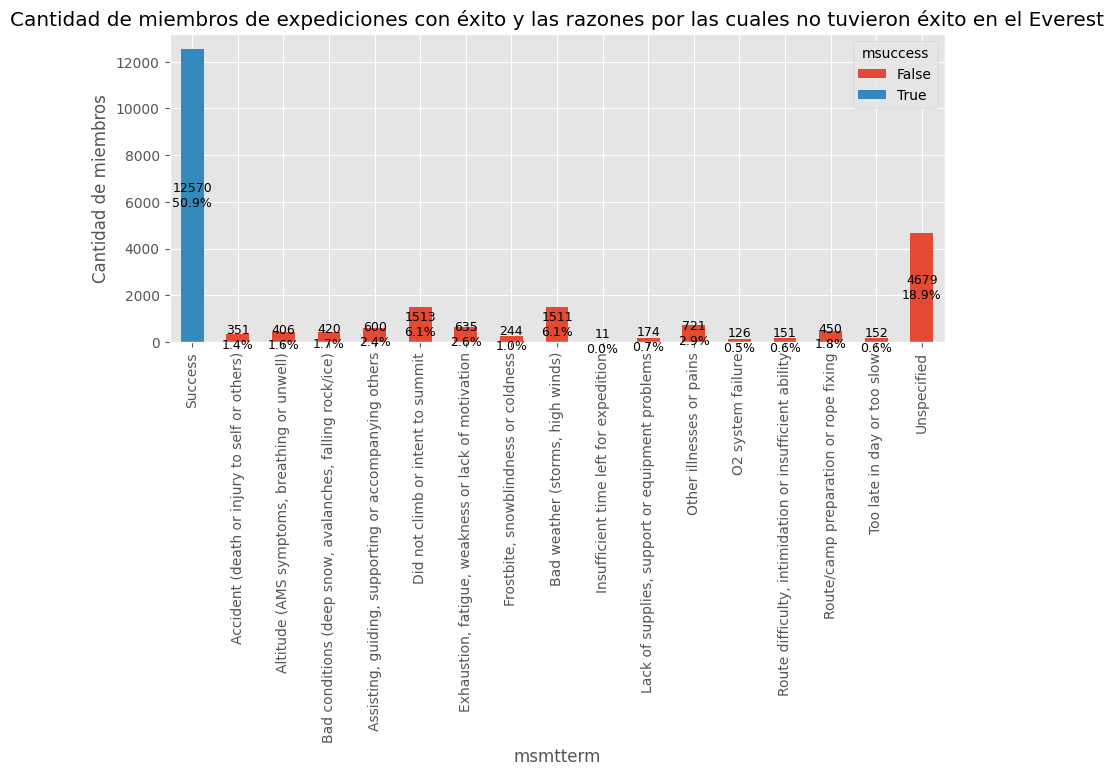

In [60]:
# Agrupar por 'msmtterm' y 'msuccess', contar miembros únicos por cada combinación
miembros_success_everest = df_everest.groupby(['msmtterm', 'msuccess'])['expid'].count().unstack(fill_value=0).sort_values(by=True, ascending=False)

ax = miembros_success_everest.plot(kind='bar', stacked=True, figsize=(10, 4))
plt.title('Cantidad de miembros de expediciones con éxito y las razones por las cuales no tuvieron éxito en el Everest')
plt.xlabel('msmtterm')
plt.ylabel('Cantidad de miembros')
plt.legend(title='msuccess')
plt.tight_layout()

# Calcular el total general
total_general = miembros_success_everest.values.sum()

# Añadir porcentajes sobre cada barra (para cada segmento, respecto al total general)
for i, msmtterm in enumerate(miembros_success_everest.index):
    for j, success in enumerate(miembros_success_everest.columns):
        valor = miembros_success_everest.loc[msmtterm, success]
        porcentaje = valor / total_general * 100 if total_general > 0 else 0
        if valor > 0:
            ax.text(i, miembros_success_everest.loc[msmtterm].cumsum()[success] - valor/2,
                    f'{valor}\n{porcentaje:.1f}%', ha='center', va='center', fontsize=9, color='black')

plt.show()

In [61]:
# Agrupar por ocupación y éxito, contar miembros únicos por cada combinación
sherpa_success = df_everest.groupby(['sherpa', 'msuccess'])['expid'].count()
sherpa_success = sherpa_success.sort_values(ascending=False)
sherpa_success

sherpa  msuccess
False   False       10565
        True         7024
True    True         5546
        False        1579
Name: expid, dtype: int64

In [62]:
sherpa_success_hamalaya = df_copy.groupby(['sherpa', 'msuccess'])['expid'].count()
sherpa_success_hamalaya = sherpa_success_hamalaya.sort_values(ascending=False)
sherpa_success_hamalaya

sherpa  msuccess
False   False       45162
        True        24316
True    True        11896
        False        5089
Name: expid, dtype: int64

In [63]:
# To get the unique values in the 'status' column:
df_copy['status'].unique()
df_copy['status'].value_counts().head(20)


status
Climber              50048
H-A Worker           18145
Leader               10813
Exp Doctor            1395
Deputy Leader         1206
Sirdar                 578
H-A Assistant          389
BC Manager             369
Climbing Leader        369
Co-Leader              344
Member                 315
Climbing Guide         205
Rope-Fixing            148
Film Team              137
Cameraman              123
Journalist              56
Climber (torch)         49
Scientist               43
Climber (S)             37
Leader/Exp Doctor       36
Name: count, dtype: int64

In [64]:
# Agrupar por 'status' y 'msuccess', contar miembros únicos por cada combinación
status_success_ever = df_everest.groupby(['status', 'msuccess'])['membid'].count().unstack(fill_value=0)

# Ordenar por la cantidad de éxitos (True) en orden descendente
status_success_ever = status_success_ever.sort_values(by=True, ascending=False)
status_success_ever.head(20)

msuccess,False,True
status,,
H-A Worker,1531,5982
Climber,7297,4856
Leader,1325,885
H-A Assistant,71,204
Deputy Leader,213,118
Climbing Guide,40,96
Rope-Fixing,3,61
Sirdar,81,48
Climbing Leader,72,44


In [65]:
# Agrupar por 'status' y 'msuccess', contar miembros únicos por cada combinación
status_success = df_copy.groupby(['status', 'msuccess'])['membid'].count().unstack(fill_value=0)

# Ordenar por la cantidad de éxitos (True) en orden descendente
status_success = status_success.sort_values(by=True, ascending=False)
status_success.head(20)

msuccess,False,True
status,,
Climber,32871,17177
H-A Worker,5131,13014
Leader,6717,4096
Deputy Leader,825,381
H-A Assistant,94,295
Sirdar,401,177
Co-Leader,192,152
Exp Doctor,1247,148
Climbing Leader,225,144


In [66]:
df_copy['mascent3'].unique()

array([  0,   4,   8, 111,  59,  12,   5,   7])

In [67]:

def eliminar_alta_cardinalidad(df, target_column='death', umbral=2, excepciones=None):
    """
    Elimina columnas categóricas de alta cardinalidad del DataFrame.

    Parámetros:
    - df: DataFrame original.
    - target_column: columna objetivo a conservar.
    - umbral: porcentaje máximo de cardinalidad permitido.
    - excepciones: lista de columnas que no se deben eliminar.

    Devuelve:
    - df filtrado.
    - lista de columnas eliminadas.
    """
    if excepciones is None:
        excepciones = []

    columnas_eliminadas = []

    columnas_cat = df.drop(columns=[target_column], errors='ignore')\
                     .select_dtypes(include=['object', 'category']).columns

    cardinalidad = df[columnas_cat].nunique() * 100 / df.shape[0]

    cols = [col for col in cardinalidad[cardinalidad > umbral].index if col not in excepciones]

    for col in cols:
        print(f"🗑️ Eliminando '{col}' con {df[col].nunique()} categorías únicas ({cardinalidad[col]:.2f}%)")
        df.drop(columns=col, inplace=True)
        columnas_eliminadas.append(col)

    return df, columnas_eliminadas




In [68]:
# Aplicar la función para eliminar columnas de alta cardinalidad
eliminar_alta_cardinalidad(df_copy, target_column='death', umbral=0.8, excepciones=['mseason', 'msuccess'])

🗑️ Eliminando 'expid' con 11315 categorías únicas (13.09%)
🗑️ Eliminando 'fname' con 20699 categorías únicas (23.94%)
🗑️ Eliminando 'lname' con 24524 categorías únicas (28.36%)
🗑️ Eliminando 'residence' con 14767 categorías únicas (17.08%)
🗑️ Eliminando 'occupation' con 14691 categorías únicas (16.99%)


(       membid peakid  myear mseason sex     yob      citizen      status  \
 0           2   AMAD   2001  Spring   M  1972.0    Australia     Climber   
 1           1   AMAD   2001  Spring   M  1968.0    Australia      Leader   
 2           3   AMAD   2001  Spring   M  1960.0    Australia     Climber   
 3           4   AMAD   2001  Spring   M  1966.0    Australia     Climber   
 4           5   AMAD   2001  Spring   F  1970.0    Australia     Climber   
 ...       ...    ...    ...     ...  ..     ...          ...         ...   
 88981       4   GIMM   1920  Summer   M  1886.0        Nepal  H-A Worker   
 88982       1   LNPS   1920  Summer   M  1893.0  Switzerland      Leader   
 88990       9   LNPS   1907  Summer   M  1869.0        Nepal  H-A Worker   
 88996       3   SURM   1905  Spring   M  1863.0           UK  Exp Doctor   
 88998       5   SURM   1905  Spring   M  1863.0           UK     Climber   
 
        leader  deputy  ...  mo2descent  mo2sleep  mo2medical  death  \
 0

In [69]:
df_copy.infodf = info_modulo(df_copy)
df_copy.infodf.info_dataframe()

Tamaño: (86463, 46)


Variables nulos: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nulos]
Index: []


Variables NAN: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nan o vacíos]
Index: []


Informacion dataframe: 
<class 'pandas.core.frame.DataFrame'>
Index: 86463 entries, 0 to 88998
Data columns (total 46 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   membid      86463 non-null  int64   
 1   peakid      86463 non-null  object  
 2   myear       86463 non-null  int64   
 3   mseason     86463 non-null  object  
 4   sex         86463 non-null  object  
 5   yob         86463 non-null  float64 
 6   citizen     86463 non-null  object  
 7   status      86463 non-null  object  
 8   leader      86463 non-null  bool    
 9   deputy      86463 non-null  bool    
 10  bconly      86463 non-null  bool    
 11  nottobc     86463 non-null  bool    
 12  support     86463 non-null  bool    
 13  disabled    86463 non-null

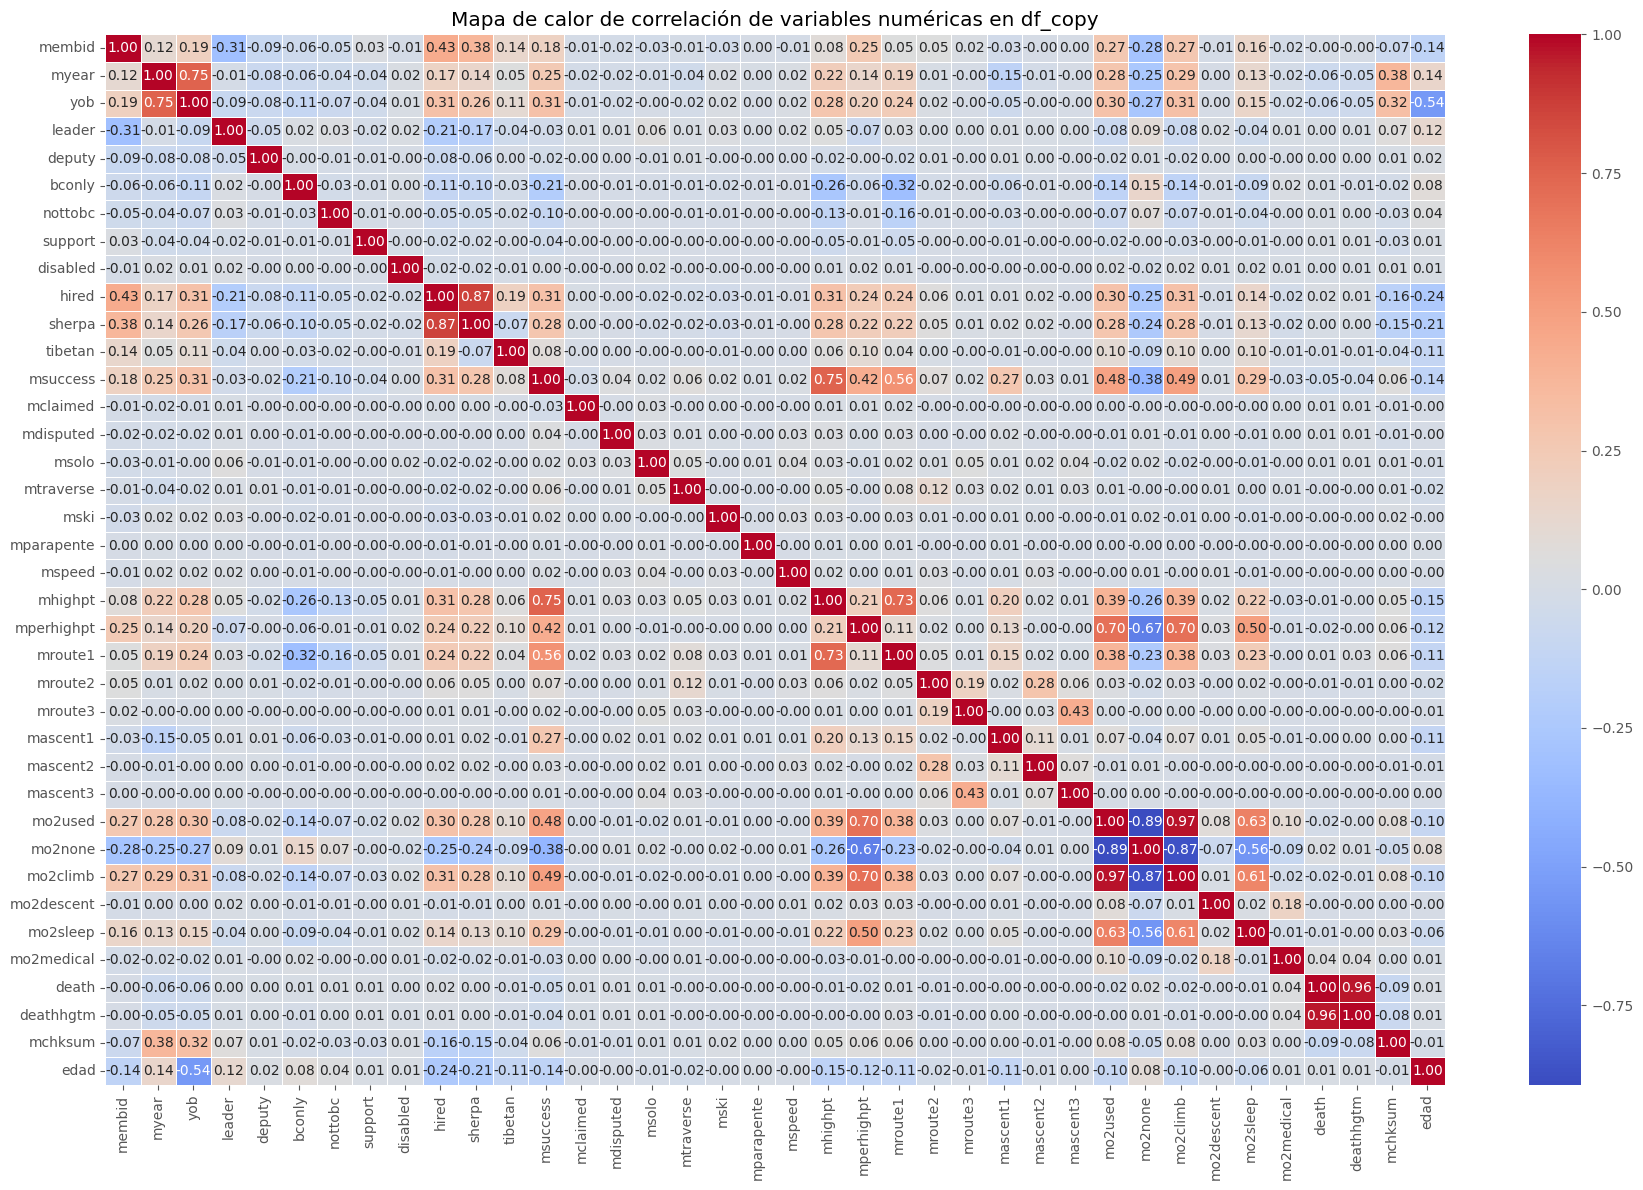

In [70]:
# Mapa de calor de correlación para df_copy
plt.figure(figsize=(18, 12))
corr = df_copy.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de calor de correlación de variables numéricas en df_copy')
plt.tight_layout()
plt.show()

In [71]:
df_copy = df_copy.drop(['citizen', 'peakid', 'status'], axis=1)

In [72]:
def eliminar_correlacionadas(df, target_column=None, umbral=0.75):
    """
    Convierte columnas bool y object a numéricas y elimina columnas altamente correlacionadas.
    """
    df = df.copy()

    # 1. Convertir columnas booleanas a enteros
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    # 2. One-hot encoding para columnas object
    obj_cols = df.select_dtypes(include='object').columns
    df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

    # 3. Eliminar columnas objetivo si están especificadas
    if target_column is not None:
        if isinstance(target_column, str):
            drop_cols = [target_column]
        else:
            drop_cols = list(target_column)
        num_df = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    else:
        num_df = df.select_dtypes(include=[np.number])

    # 4. Calcular matriz de correlación
    corr = num_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # 5. Identificar columnas a eliminar
    to_drop = [col for col in upper.columns if any(upper[col] > umbral)]

    # 6. Eliminar columnas del DataFrame original (no del que se codificó)
    df_final = df.drop(columns=to_drop)

    print(f"Columnas eliminadas por alta correlación: {to_drop}")
    return df_final, to_drop


In [73]:
df_copy, columnas_eliminadas = eliminar_correlacionadas(df_copy, target_column=['death', 'msmtbid_Successful summit bid'], umbral=0.75)


Columnas eliminadas por alta correlación: ['yob', 'sherpa', 'mhighpt', 'mo2none', 'mo2climb']


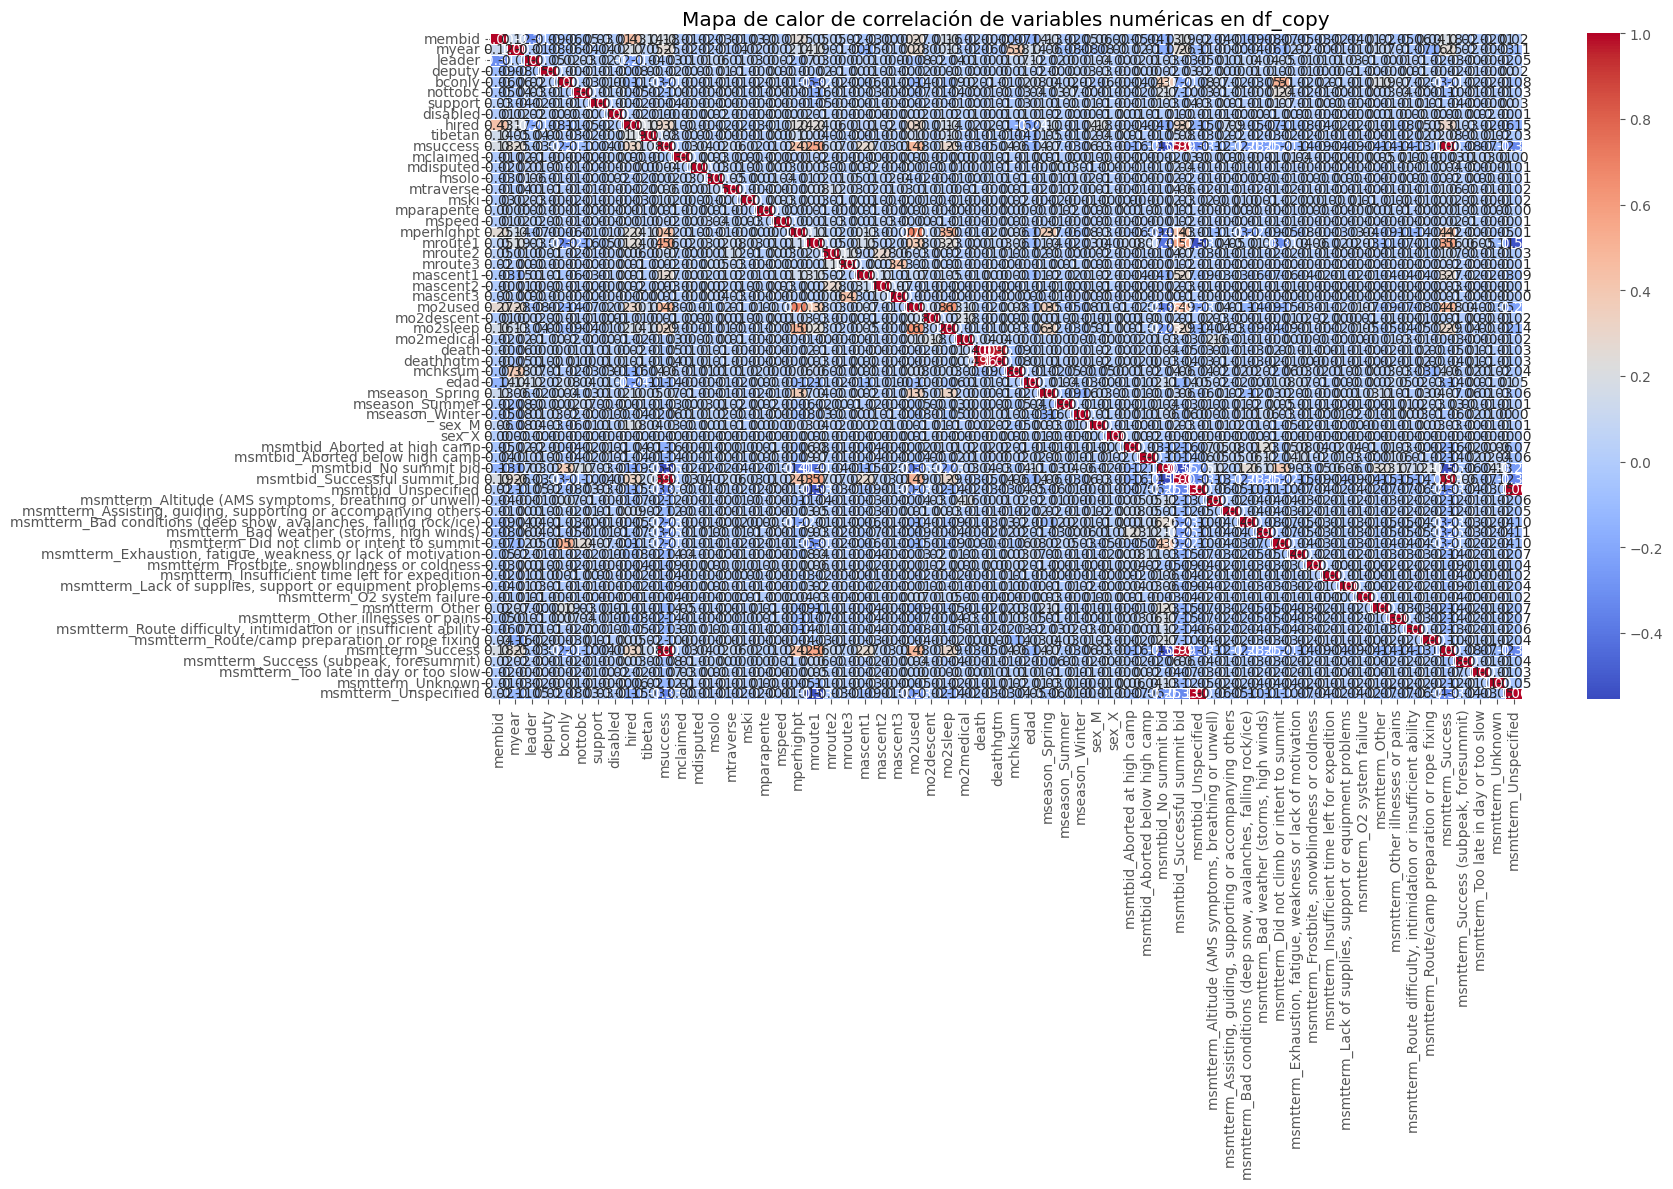

In [74]:
# Mapa de calor de correlación para df_copy
plt.figure(figsize=(18, 12))
corr = df_copy.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de calor de correlación de variables numéricas en df_copy')
plt.tight_layout()
plt.show()

In [75]:
df_copy.infodf = info_modulo(df_copy)
df_copy.infodf.info_dataframe()

Tamaño: (86463, 63)


Variables nulos: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nulos]
Index: []


Variables NAN: 
Empty DataFrame
Columns: [Nombre Variable, Cantidad de Nan o vacíos]
Index: []


Informacion dataframe: 
<class 'pandas.core.frame.DataFrame'>
Index: 86463 entries, 0 to 88998
Data columns (total 63 columns):
 #   Column                                                             Non-Null Count  Dtype   
---  ------                                                             --------------  -----   
 0   membid                                                             86463 non-null  int64   
 1   myear                                                              86463 non-null  int64   
 2   leader                                                             86463 non-null  int64   
 3   deputy                                                             86463 non-null  int64   
 4   bconly                                                             86463 n

In [76]:

orden = {'13-17': 1, '18-22': 2, '23-27': 3, '28-32': 4, '33-37': 5, '38-42': 6, '43-47': 7,'48-52': 8, '53-57': 9, '58-62': 10, '63-67': 11, '68-72': 12, '73-77': 13, '78-82': 14}
df_copy['rango_edad_ordinal'] = df_copy['edad_rango'].map(orden)
df_copy['rango_edad_ordinal'] = df_copy['rango_edad_ordinal'].astype(int)
df_copy = df_copy.drop(columns=['edad_rango'])  # usa el nombre exacto de la columna


In [77]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

class modelo_ml_binario:
    def __init__(self, x, y):
        self.x = x.copy()
        self.y = y.copy()

    def division_datos(self, tamano, seed_number, estratificar='NO'):
        if estratificar.upper() == 'SI':
            return train_test_split(self.x, self.y, test_size=tamano, random_state=seed_number, stratify=self.y)
        else:
            return train_test_split(self.x, self.y, test_size=tamano, random_state=seed_number)

    def entrenar(self, modelo, seed_number=42, tamano=0.2, escalar='NO', escala_func=None,
                 estimador='accuracy', tipo='CLASIFICACION', estratificar='SI'):
        X_train, X_test, y_train, y_test = self.division_datos(tamano, seed_number, estratificar)
        
        # Renombrar columnas antes de escalar
        X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
        X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

        if escalar.upper() == 'SI' and escala_func is not None:
            X_train = escala_func.fit_transform(X_train)
            X_test = escala_func.transform(X_test)



        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_pred_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None

        if estimador == 'accuracy':
            train_score = modelo.score(X_train, y_train)
            test_score = accuracy_score(y_test, y_pred)
        elif estimador == 'recall':
            test_score = recall_score(y_test, y_pred)
            train_score = None
        elif estimador == 'f1_score':
            test_score = f1_score(y_test, y_pred)
            train_score = None
        elif estimador == 'roc' and y_pred_proba is not None:
            test_score = roc_auc_score(y_test, y_pred_proba)
            train_score = None
        else:
            test_score = None
            train_score = None

        return {
            'modelo': modelo,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'accuracy': test_score if estimador == 'accuracy' else None,
            'recall': recall_score(y_test, y_pred) if estimador in ['accuracy','recall','f1_score'] else None,
            'f1': f1_score(y_test, y_pred) if estimador in ['accuracy','recall','f1_score'] else None,
            'roc_auc': roc_auc_score(y_test, y_pred_proba) if estimador=='roc' else None
        }


In [78]:
# Preparar datos
X = df_copy.drop(columns=['death','msmtbid_Successful summit bid'])
y_death = df_copy['death']
y_success = df_copy['msmtbid_Successful summit bid']

# Instanciar objetos
m_death = modelo_ml_binario(X, y_death)
m_success = modelo_ml_binario(X, y_success)

# Definir modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

modelos = {
    'RF': RandomForestClassifier(
    n_estimators=200,             # número de árboles
    max_depth=15,                 # profundidad máxima del árbol
    min_samples_split=10,         # mínimo de muestras para dividir un nodo
    min_samples_leaf=5,           # mínimo de muestras en una hoja
    max_features='sqrt',          # número de features a considerar por división
    class_weight='balanced',      # muy importante para desbalance
    random_state=42,
    n_jobs=-1                     # usar todos los núcleos disponibles
),
    'LR': LogisticRegression(
    penalty='l2',                 # regularización ridge
    C=1.0,                        # inverso de la fuerza de regularización
    solver='lbfgs',              # bueno para datasets pequeños-medianos
    max_iter=2000,               # más iteraciones para converger
    class_weight='balanced',     # ajusta pesos automáticamente según clases
    random_state=42
),
    'XGB': XGBClassifier(objective='binary:logistic',
    eval_metric='auc',
    #use_label_encoder=False,     # para evitar warnings
    scale_pos_weight=75,         # proporción de negativos/positivos ≈ 68264/906
    learning_rate=0.05,
    n_estimators=200,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1),
    
'LGBM': LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    is_unbalance=True,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_data_in_leaf=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    verbose=-1,
    n_estimators=200,
    force_col_wise=True  # útil si hay problemas de memoria
)
}

resultados = {}
for name, model in modelos.items():
    res_death = m_death.entrenar(modelo=model, estimador='accuracy')
    res_success = m_success.entrenar(modelo=model, estimador='accuracy')
    resultados[name] = {
        'death': res_death,
        'msmtbid_Successful summit bid': res_success
    }


c:\Users\Fabrizio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [79]:
# Crear DataFrame de resultados
metricas = ['accuracy', 'recall', 'f1', 'roc_auc']
resumen = []

for modelo, resultados_modelo in resultados.items():
    fila = {'modelo': modelo}
    for target in ['death', 'msmtbid_Successful summit bid']:
        for metrica in metricas:
            key = f'{target}_{metrica}'
            fila[key] = resultados_modelo[target].get(metrica)
    resumen.append(fila)

df_resultados = pd.DataFrame(resumen)
df_resultados = df_resultados.applymap(lambda x: np.nan if x is None else x)
pd.set_option('display.float_format', '{:.3f}'.format)
display(df_resultados)

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\1266217755.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_resultados = df_resultados.applymap(lambda x: np.nan if x is None else x)


,modelo,death_accuracy,death_recall,death_f1,death_roc_auc,msmtbid_Successful summit bid_accuracy,msmtbid_Successful summit bid_recall,msmtbid_Successful summit bid_f1,msmtbid_Successful summit bid_roc_auc
0,RF,0.999,0.960,0.980,NaN,0.999,0.999,0.999,NaN
1,LR,0.997,0.965,0.888,NaN,0.997,0.996,0.997,NaN
2,XGB,0.999,0.965,0.978,NaN,1.000,1.000,1.000,NaN
3,LGBM,0.999,0.960,0.980,NaN,1.000,1.000,1.000,NaN


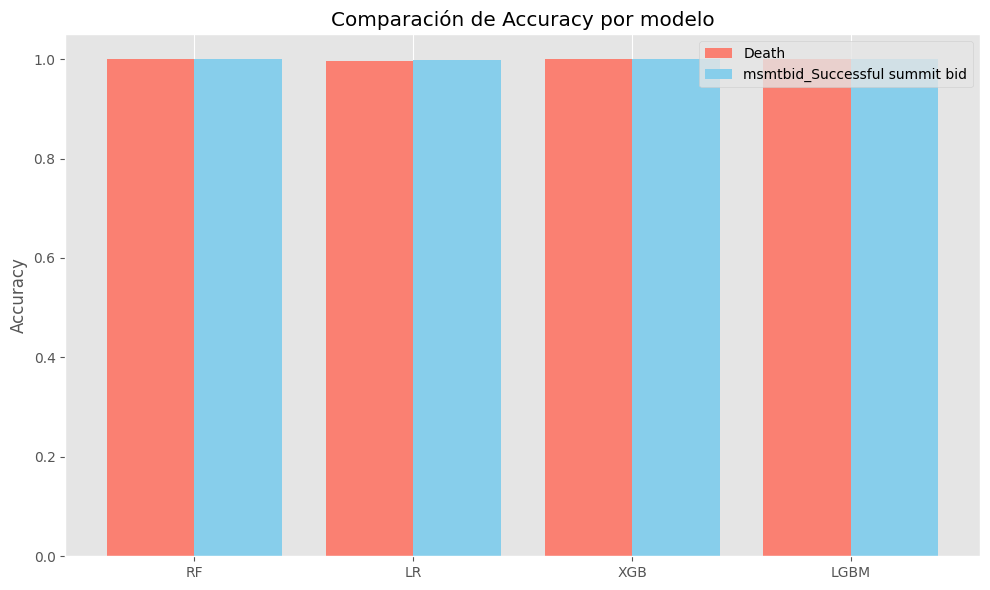

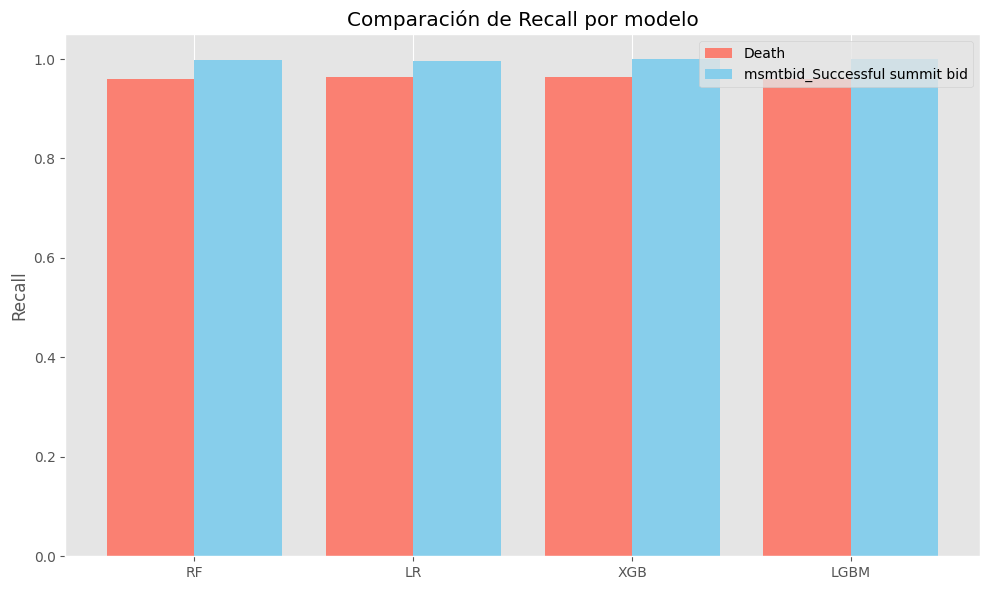

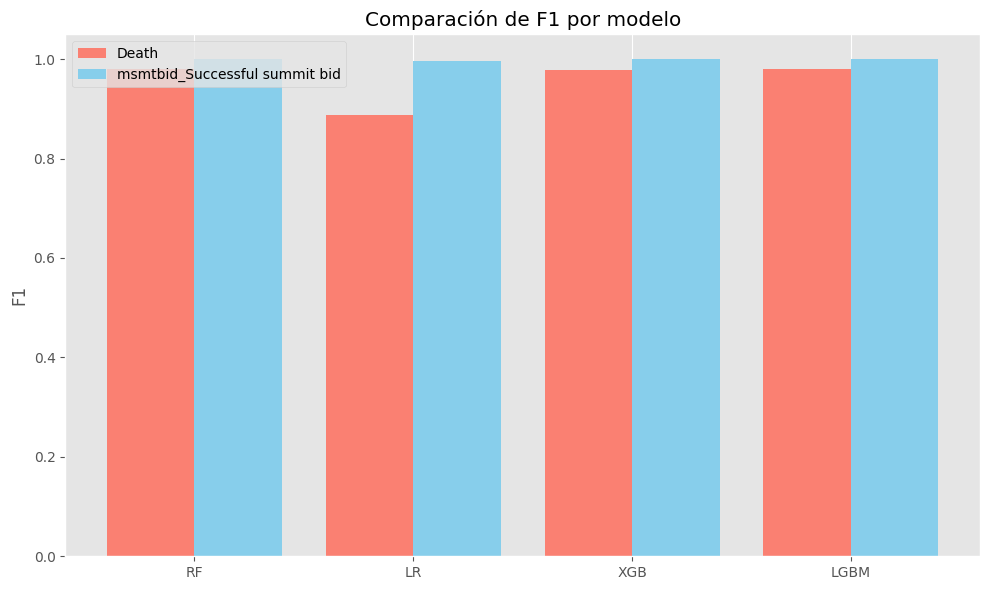

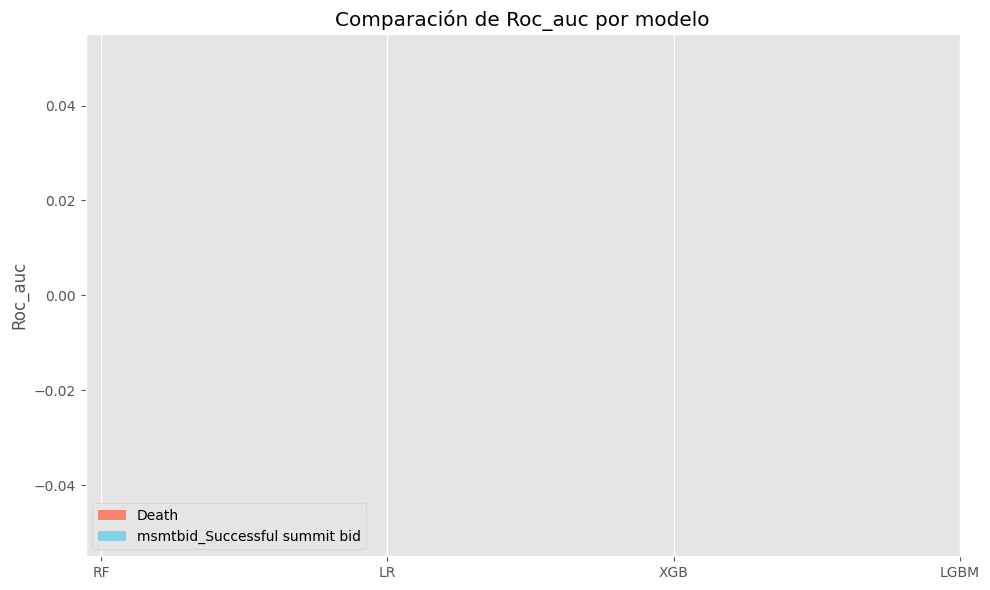

In [80]:


def plot_metric(metric_name):
    labels = df_resultados['modelo']
    x = range(len(labels))
    
    plt.figure(figsize=(10, 6))
    plt.bar([i - 0.2 for i in x], df_resultados[f'death_{metric_name}'], width=0.4, label='Death', color='salmon')
    plt.bar([i + 0.2 for i in x], df_resultados[f'msmtbid_Successful summit bid_{metric_name}'], width=0.4, label='msmtbid_Successful summit bid', color='skyblue')
    
    plt.xticks(x, labels)
    plt.ylabel(metric_name.capitalize())
    plt.title(f'Comparación de {metric_name.capitalize()} por modelo')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Mostrar gráficos para cada métrica
for metrica in metricas:
    plot_metric(metrica)


In [81]:
# Obtener X_test e y_test usando el método division_datos del objeto m_success
X_train, X_test, y_train, y_test = m_success.division_datos(tamano=0.2, seed_number=42, estratificar='SI')

print("Test distribution:", y_test.value_counts(normalize=True))

Test distribution: msmtbid_Successful summit bid
False   0.574
True    0.426
Name: proportion, dtype: float64


In [82]:
from sklearn.metrics import balanced_accuracy_score, precision_recall_curve, average_precision_score

# Obtener X_test e y_test usando el método division_datos del objeto m_success
# (ajusta m_success a m_death si quieres predecir muerte)
X_train, X_test, y_train, y_test = m_success.division_datos(tamano=0.2, seed_number=42, estratificar='SI')

# Usar el modelo entrenado correspondiente
model = resultados['LGBM']['msmtbid_Successful summit bid']['modelo']

# Renombrar columnas de X_test igual que en el entrenamiento
X_test = X_test.copy()
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # para la clase positiva

bal_acc = balanced_accuracy_score(y_test, y_pred)
avg_prec = average_precision_score(y_test, y_proba)

prec, rec, thresholds = precision_recall_curve(y_test, y_proba)


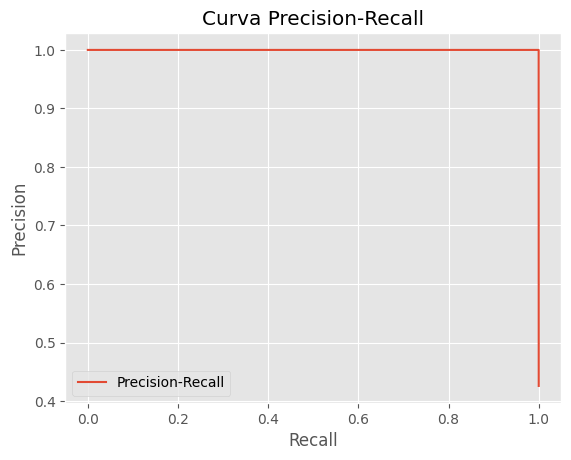

In [83]:
import matplotlib.pyplot as plt

plt.plot(rec, prec, label='Precision-Recall')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.show()


In [84]:
y_proba = resultados['RF']['msmtbid_Successful summit bid']['y_pred_proba']
y_true = resultados['RF']['msmtbid_Successful summit bid']['y_test']
print("Balanced accuracy:", balanced_accuracy_score(y_true, resultados['RF']['msmtbid_Successful summit bid']['y_pred']))
print("Average precision:", average_precision_score(y_true, y_proba))

Balanced accuracy: 0.9994064594087877
Average precision: 0.9999986213284396


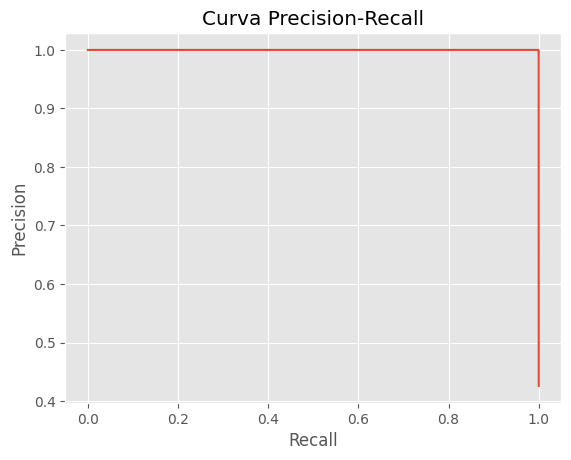

In [85]:
prec, rec, _ = precision_recall_curve(y_true, y_proba)
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True)
plt.show()

In [86]:
def filtrar_columnas(df, target):
    columnas_a_excluir = [
        'msuccess', 'death', 'mclaimed', 'mdisputed', 'mperhighpt',
        'mo2used', 'mo2descent', 'mo2sleep', 'mo2medical',
    ]
    
    columnas_msmtterm = [col for col in df.columns if col.startswith('msmtterm_')]
    columnas_msmtbid = [col for col in df.columns if col.startswith('msmtbid_')]
    
    # Evitar quitar el target que estés usando
    columnas_a_excluir = [col for col in columnas_a_excluir if col != target]
    
    columnas_a_excluir += [col for col in columnas_msmtterm if col != target]
    columnas_a_excluir += [col for col in columnas_msmtbid if col != target]

    X = df.drop(columns=columnas_a_excluir + [target])
    y = df[target]
    return X, y


In [87]:
X, y_success = filtrar_columnas(df_copy, 'msmtbid_Successful summit bid')
X, y_death = filtrar_columnas(df_copy, 'death')


In [88]:
m_death = modelo_ml_binario(X, y_death)
m_success = modelo_ml_binario(X, y_success)


In [89]:
resultados = {}
for name, model in modelos.items():
    res_death = m_death.entrenar(modelo=model, estimador='accuracy')
    res_success = m_success.entrenar(modelo=model, estimador='accuracy')
    resultados[name] = {
        'death': res_death,
        'msmtbid_Successful summit bid': res_success
    }


In [90]:
# Crear DataFrame de resultados
metricas = ['accuracy', 'recall', 'f1', 'roc_auc']
resumen = []

for modelo, resultados_modelo in resultados.items():
    fila = {'modelo': modelo}
    for target in ['death', 'msmtbid_Successful summit bid']:
        for metrica in metricas:
            key = f'{target}_{metrica}'
            fila[key] = resultados_modelo[target].get(metrica)
    resumen.append(fila)

df_resultados = pd.DataFrame(resumen)
df_resultados = df_resultados.applymap(lambda x: np.nan if x is None else x)
pd.set_option('display.float_format', '{:.3f}'.format)
display(df_resultados)

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_12996\1266217755.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_resultados = df_resultados.applymap(lambda x: np.nan if x is None else x)


,modelo,death_accuracy,death_recall,death_f1,death_roc_auc,msmtbid_Successful summit bid_accuracy,msmtbid_Successful summit bid_recall,msmtbid_Successful summit bid_f1,msmtbid_Successful summit bid_roc_auc
0,RF,0.999,0.960,0.980,NaN,0.859,0.948,0.852,NaN
1,LR,0.999,0.956,0.977,NaN,0.799,0.770,0.766,NaN
2,XGB,0.999,0.965,0.971,NaN,0.830,0.999,0.834,NaN
3,LGBM,0.999,0.960,0.975,NaN,0.871,0.935,0.861,NaN


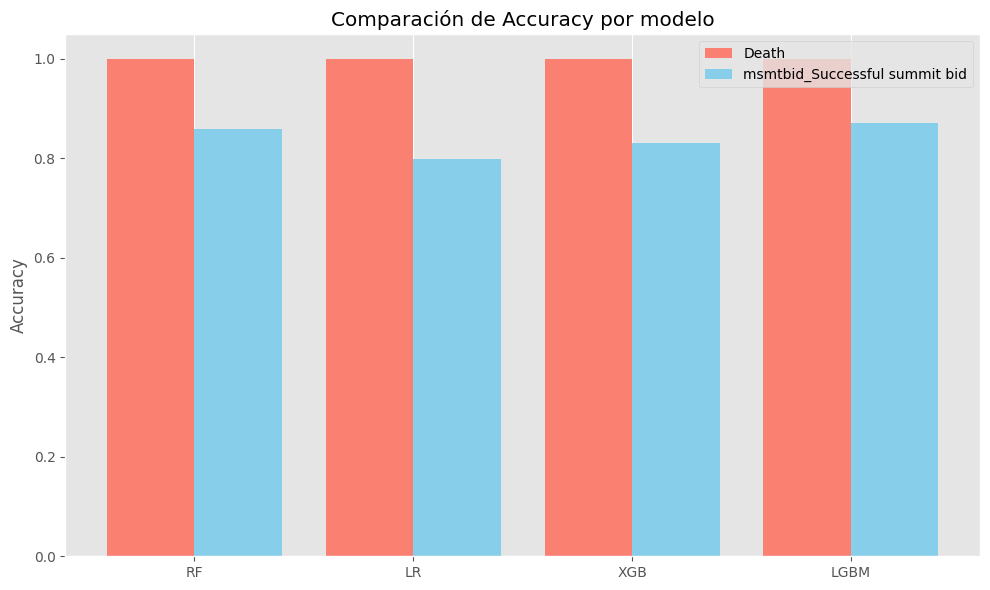

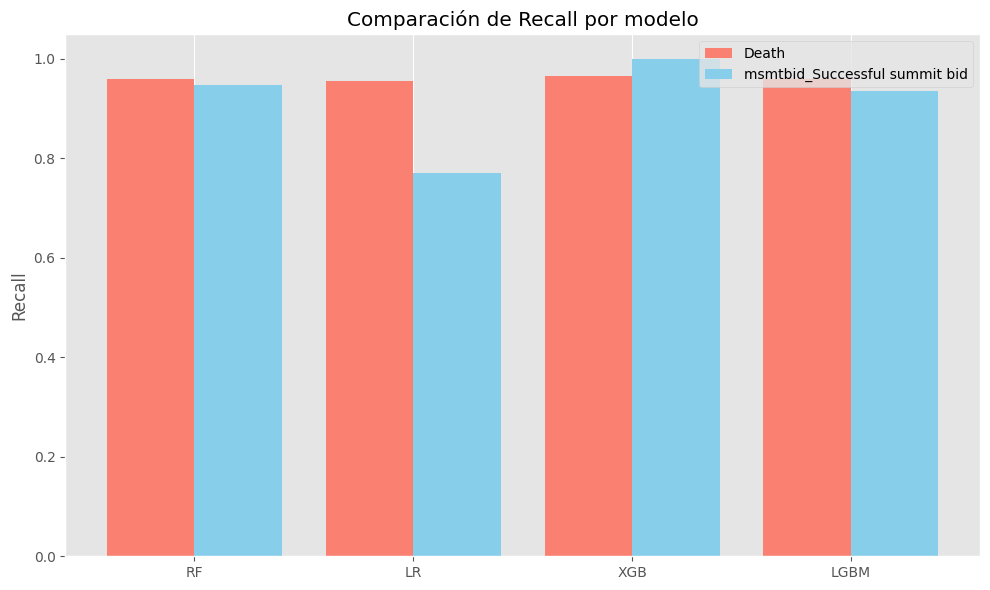

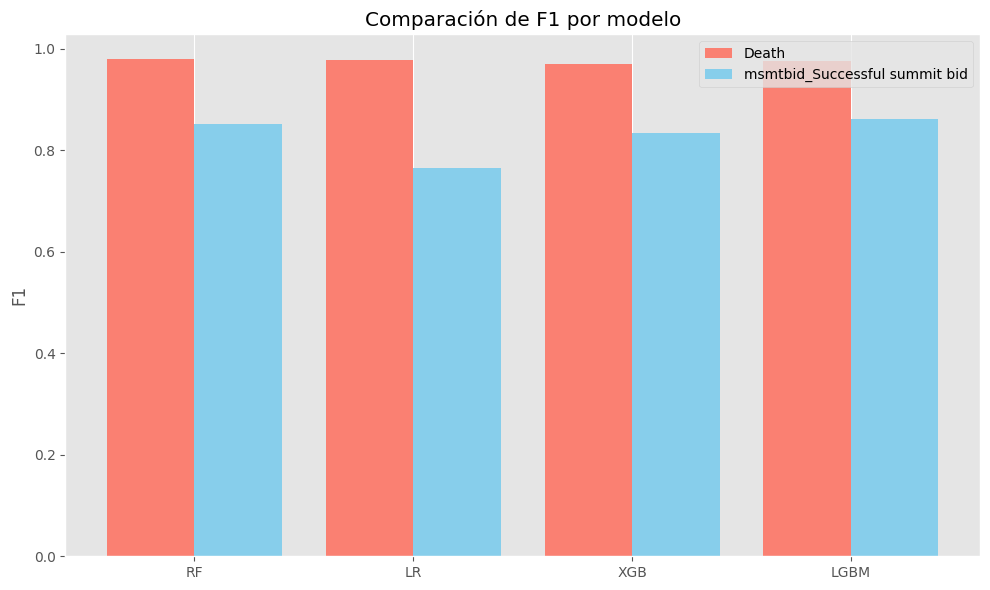

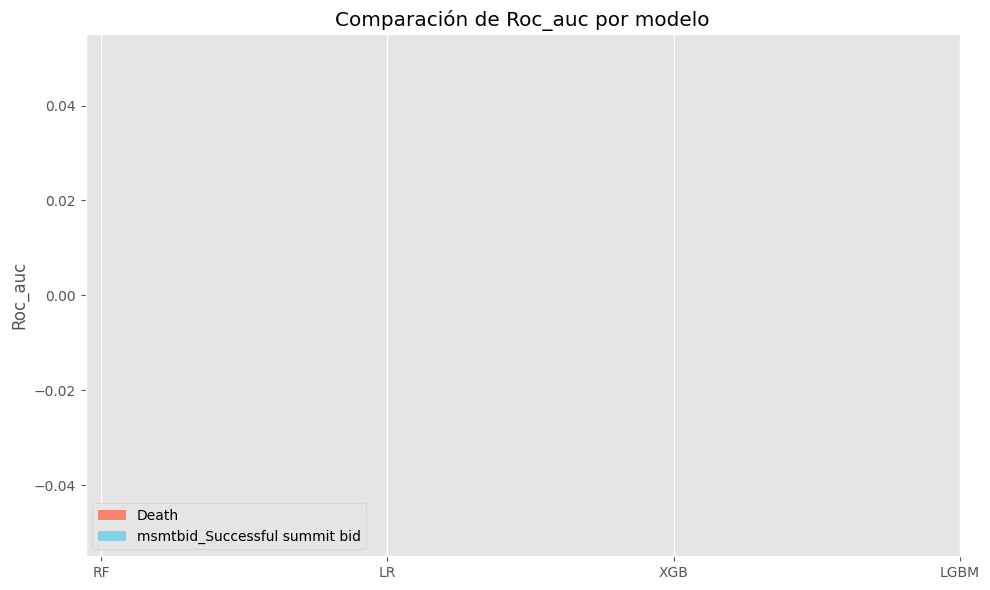

In [91]:


def plot_metric(metric_name):
    labels = df_resultados['modelo']
    x = range(len(labels))
    
    plt.figure(figsize=(10, 6))
    plt.bar([i - 0.2 for i in x], df_resultados[f'death_{metric_name}'], width=0.4, label='Death', color='salmon')
    plt.bar([i + 0.2 for i in x], df_resultados[f'msmtbid_Successful summit bid_{metric_name}'], width=0.4, label='msmtbid_Successful summit bid', color='skyblue')
    
    plt.xticks(x, labels)
    plt.ylabel(metric_name.capitalize())
    plt.title(f'Comparación de {metric_name.capitalize()} por modelo')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Mostrar gráficos para cada métrica
for metrica in metricas:
    plot_metric(metrica)


In [92]:
X_train, X_test, y_train, y_test = m_success.division_datos(tamano=0.2, seed_number=42, estratificar='SI')

# Usar el modelo entrenado correspondiente
model = resultados['LGBM']['msmtbid_Successful summit bid']['modelo']

# Renombrar columnas de X_test igual que en el entrenamiento
X_test = X_test.copy()
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # para la clase positiva

bal_acc = balanced_accuracy_score(y_test, y_pred)
avg_prec = average_precision_score(y_test, y_proba)

prec, rec, thresholds = precision_recall_curve(y_test, y_proba)


In [93]:
y_proba = resultados['RF']['msmtbid_Successful summit bid']['y_pred_proba']
y_true = resultados['RF']['msmtbid_Successful summit bid']['y_test']
print("Balanced accuracy:", balanced_accuracy_score(y_true, resultados['RF']['msmtbid_Successful summit bid']['y_pred']))
print("Average precision:", average_precision_score(y_true, y_proba))

Balanced accuracy: 0.8706789826453316
Average precision: 0.9401383043781197


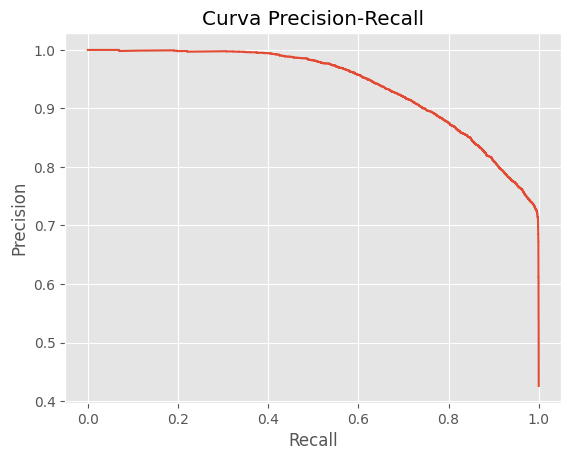

In [94]:
prec, rec, _ = precision_recall_curve(y_true, y_proba)
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.grid(True)
plt.show()

In [101]:


resultados = {}
for name, model in modelos.items():
    # Para death
    res_death = m_death.entrenar(modelo=model, estimador='accuracy')
    # Para success
    res_success = m_success.entrenar(modelo=model, estimador='accuracy')
    
    # Guardar también los datos de prueba
    resultados[name] = {
        'death': {
            'modelo': res_death['modelo'],
            'X_test': m_death.X_test,  # Añadir X_test
            'y_test': m_death.y_test   # Añadir y_test
        },
        'msmtbid_Successful summit bid': {
            'modelo': res_success['modelo'],
            'X_test': m_success.X_test,  # Añadir X_test
            'y_test': m_success.y_test   # Añadir y_test
        }
    }

AttributeError: 'modelo_ml_binario' object has no attribute 'X_test'

In [97]:
def plot_metrics(y_true, y_proba, model_name, target):
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot both curves
    plt.figure(figsize=(12, 5))
    
    # Precision-Recall
    plt.subplot(1, 2, 1)
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve\nTarget: {target}')
    plt.legend()
    
    # ROC
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve\nTarget: {target}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Evaluar todos los modelos para ambas variables objetivo
for target in ['death', 'msmtbid_Successful summit bid']:
    print(f"\n=== Análisis para {target} ===")
    for model_name in modelos.keys():
        model_info = resultados[model_name][target]
        model = model_info['modelo']
        X_test = model_info['X_test']
        y_test = model_info['y_test']
        
        # Asegurar que los nombres de columnas sean consistentes
        X_test = X_test.copy()
        X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
        
        y_proba = model.predict_proba(X_test)[:, 1]
        plot_metrics(y_test, y_proba, model_name, target)


=== Análisis para death ===


KeyError: 'RF'


=== Análisis para death ===


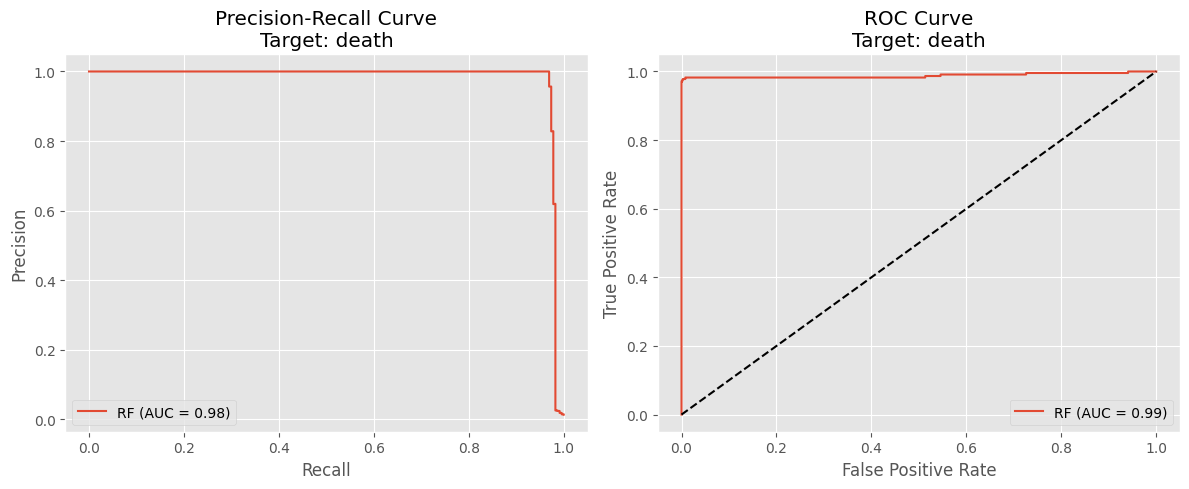

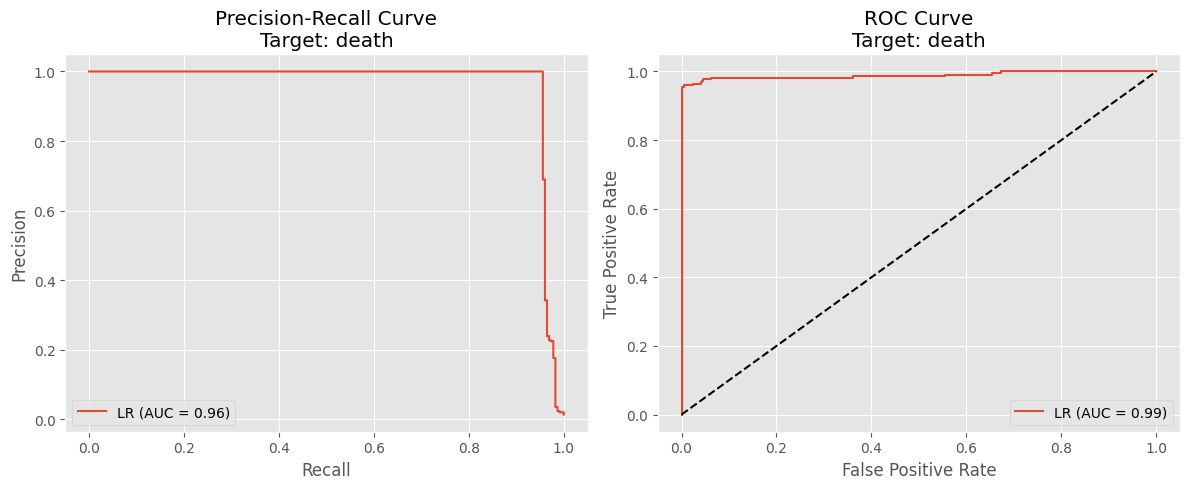

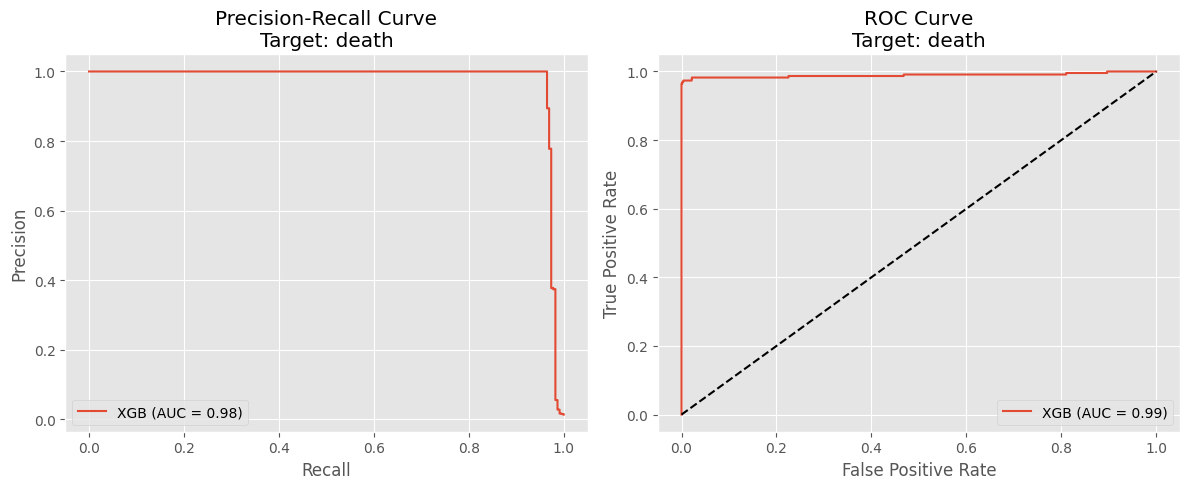

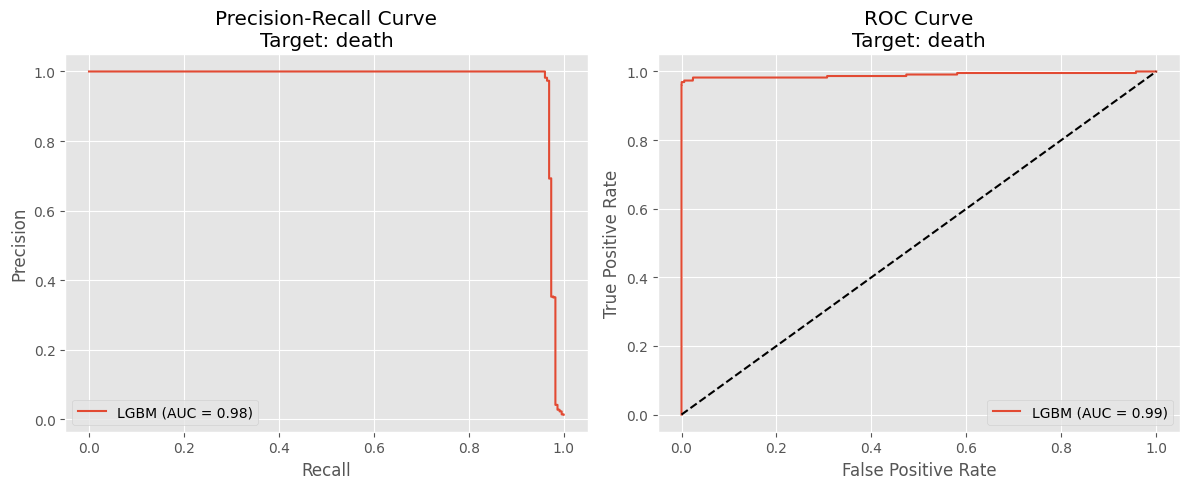


=== Análisis para msmtbid_Successful summit bid ===


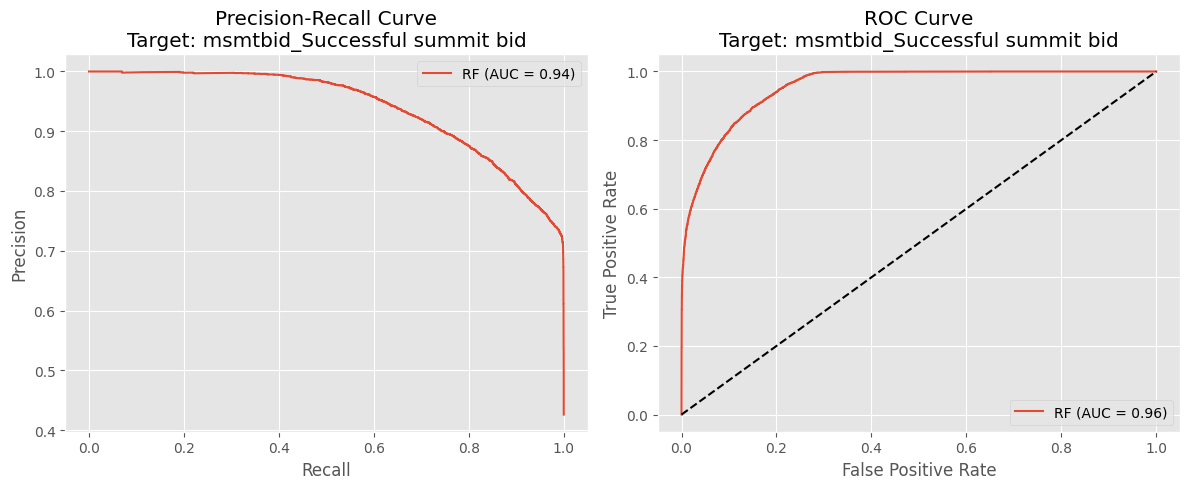

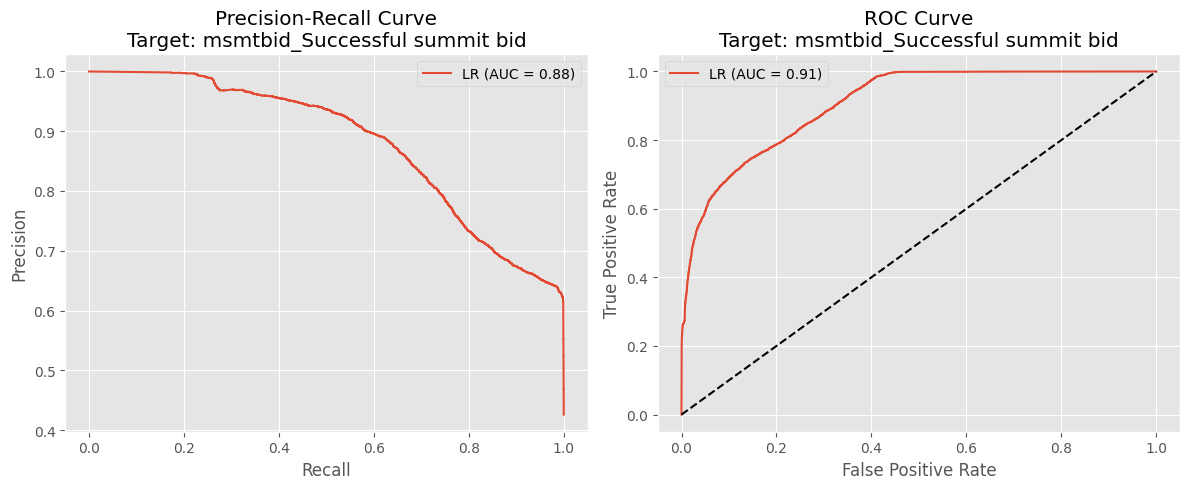

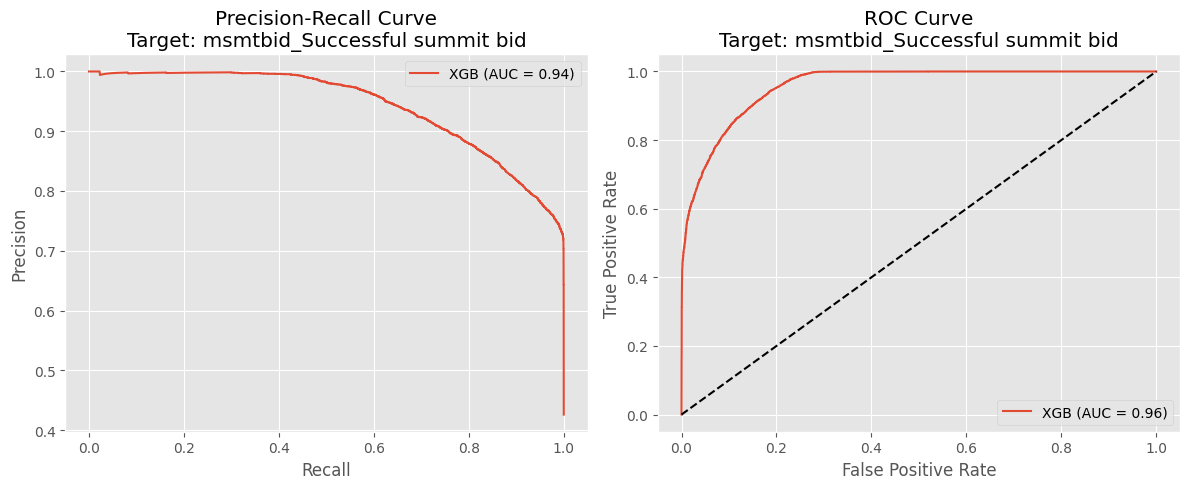

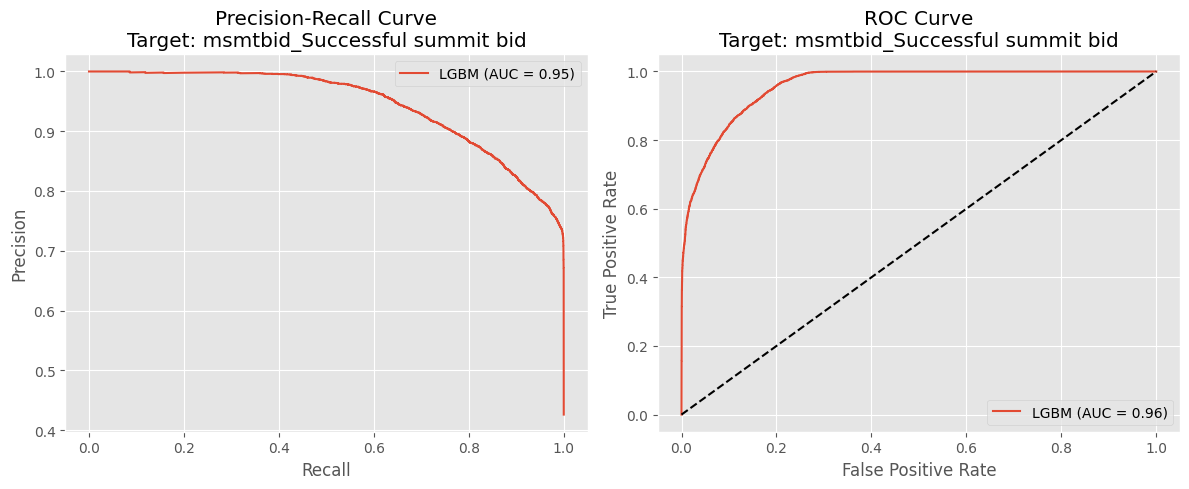

In [98]:
from sklearn.model_selection import train_test_split

for target in ['death', 'msmtbid_Successful summit bid']:
    print(f"\n=== Análisis para {target} ===")
    
    # Seleccionar y adecuado
    y = y_death if target == 'death' else y_success
    
    # Dividir datos (usando misma semilla para consistencia)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    
    for model_name, model in modelos.items():
        # Entrenar modelo
        model.fit(X_train, y_train)
        
        # Predecir probabilidades
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Graficar métricas
        plot_metrics(y_test, y_proba, model_name, target)